# Comparación de SHAP y LIME en la Explicabilidad de Modelos — US Crime
## Consistencia y Estabilidad de las Explicaciones — Predicción de Tasa de Criminalidad Violenta (Regresión)

> **Curso:** Fundamentos de Inteligencia Artificial Explicable
> **Autoras:** Alice Rambo — Fiorella Cravero

---

> **Nota de replicación.** Este notebook replica, sección por sección, el pipeline de
> `0-QSAR_XAI_Notebook.ipynb` (clasificación binaria de toxicidad molecular) pero
> adaptado a una tarea de **regresión** sobre el dataset **UCI "Communities and
> Crime" (US Crime)**, uno de los benchmarks que los propios Muñoz et al. (2023,
> arXiv:2302.12094) usan en su paper — y que ellos mismos tratan como problema de
> regresión (predicción de una tasa continua de criminalidad violenta), no como
> clasificación forzada. El objetivo es validar la reimplementación de las métricas
> Rank Consistency (RC), Importance Stability (IS) y su combinación GES sobre uno
> de los datasets originales del paper, en un escenario de regresión que el
> notebook de QSAR nunca puso a prueba (QSAR es 100% clasificación).
>
> Las funciones `rank_consistency_holistic` e `importance_stability_holistic`
> (Ecs. 4-8 del paper) son agnósticas al tipo de tarea — operan sobre cualquier
> matriz de atribuciones (n_instancias × n_features) — por lo que se copian
> **sin ningún cambio** respecto al notebook de QSAR.

### Estructura del Notebook
1. Instalación de dependencias
2. Carga y exploración de los datos (US Crime, vía `holisticai.datasets.load_dataset`)
3. Entrenamiento de modelos (validación cruzada K-Fold)
4. Evaluación predictiva sobre conjunto de prueba (R², RMSE, MAE)
5. Selección de mejores modelos + preparación de la muestra para XAI
6. Generación de explicaciones: SHAP y LIME
7. Cálculo de métricas de explicabilidad (Rank Consistency & Stability)
8. Análisis comparativo y selección del método preferido
9. Casos de mayor desacuerdo SHAP vs LIME
10. Inestabilidad local: ¿dónde falla cada método?
11. Análisis de features "conflictivas"


## 1. Instalación de Dependencias

In [1]:
import importlib.util

# En este entorno las dependencias ya estan instaladas (shap, lime, scikit-learn,
# pandas, numpy, matplotlib, seaborn, scipy, holisticai). Se evita invocar pip
# (que intentaria contactar PyPI y puede colgarse sin acceso a red) y en su lugar
# solo se instalan las que falten.
required_pkgs = {
    'shap': 'shap', 'lime': 'lime', 'sklearn': 'scikit-learn', 'pandas': 'pandas',
    'numpy': 'numpy', 'matplotlib': 'matplotlib', 'seaborn': 'seaborn',
    'scipy': 'scipy', 'holisticai': 'holisticai',
}
missing = [pip_name for mod_name, pip_name in required_pkgs.items()
           if importlib.util.find_spec(mod_name) is None]

if missing:
    import sys
    get_ipython().system(f'{sys.executable} -m pip install ' + ' '.join(missing) + ' -q')
    print('Instaladas:', missing)
else:
    print('Todas las dependencias ya estan instaladas:', list(required_pkgs.values()))

Todas las dependencias ya estan instaladas: ['shap', 'lime', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy', 'holisticai']


## 2. Carga y Exploración de Datos

A diferencia de QSAR (que leía `train.csv`/`test.csv` desde disco), US Crime se
carga directamente desde `holisticai.datasets.load_dataset('us_crime')`, que
provee el dataset "Communities and Crime" de UCI ya empaquetado. El target
`ViolentCrimesPerPop` viene normalizado en [0, 1] y se trata como variable
**continua** (regresión), tal como lo hacen Muñoz et al. (2023) en su paper.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr

PROJECT_ROOT = "C:/Users/Usuario/Documents/doctoradoUNS/holisticai-research-main"
RESULTS_DIR = Path(PROJECT_ROOT) / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

from holisticai.datasets import load_dataset
from holisticai.utils.data_preprocessor import simple_preprocessor

# ── Carga del dataset US Crime (Communities and Crime, UCI) ──────────────────
ds = load_dataset('us_crime', preprocessed=False)
ds = ds.train_test_split(test_size=0.2, random_state=42)
train, test = ds['train'], ds['test']

Xt_train, Xt_test, yt_train, yt_test = simple_preprocessor(
    train['X'], test['X'], train['y'], test['y'],
    categorical_types=['object'], model_type='regression', only_numerics=True
)

feature_names = Xt_train.columns.tolist()
X_train = Xt_train.values
X_test  = Xt_test.values
y_train = yt_train.values if hasattr(yt_train, 'values') else np.asarray(yt_train)
y_test  = yt_test.values  if hasattr(yt_test,  'values') else np.asarray(yt_test)

TARGET = 'ViolentCrimesPerPop (normalizado)'

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Features ({len(feature_names)}): {feature_names[:10]} ... (+{len(feature_names)-10} más)")
print(f"\nTarget: {TARGET}  (continuo en [0, 1])")
print("Distribución train:")
print(pd.Series(y_train).describe())
print("\nDistribución test:")
print(pd.Series(y_test).describe())

Train: (1594, 101)  |  Test: (399, 101)
Features (101): ['state', 'fold', 'population', 'householdsize', 'racepctblack', 'racePctAsian', 'racePctHisp', 'agePct12t21', 'agePct12t29', 'agePct16t24'] ... (+91 más)

Target: ViolentCrimesPerPop (normalizado)  (continuo en [0, 1])
Distribución train:
count    1594.000000
mean        0.240370
std         0.233649
min         0.000000
25%         0.070000
50%         0.160000
75%         0.330000
max         1.000000
dtype: float64

Distribución test:
count    399.000000
mean       0.228446
std        0.230651
min        0.000000
25%        0.060000
50%        0.150000
75%        0.310000
max        1.000000
dtype: float64


In [3]:
# Vista rápida de las primeras filas
Xt_train.assign(**{TARGET: y_train}).head(3)

,state,fold,population,householdsize,racepctblack,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop (normalizado)
0,-0.039828,0.523961,-0.450100,-0.368096,2.856284,-0.681200,-0.580855,0.462676,-0.358714,-0.323782,...,-0.892494,1.238710,1.025049,0.567570,-0.009617,-0.405752,-0.511824,-0.573341,-0.394924,0.31
1,-1.684849,1.567952,-0.076540,-0.674586,-0.487381,-0.397471,-0.580855,-0.593072,-0.215874,-0.448732,...,-0.631859,-0.137799,-0.768629,-0.916394,-0.776086,0.027275,-0.463085,-0.704543,-0.394924,0.09
2,1.605193,-0.520031,-0.151252,0.551375,-0.726214,-0.444759,-0.580855,-0.263150,-0.787235,-0.698633,...,-0.588419,1.091227,1.025049,-0.455853,0.859049,0.373696,-0.755521,-0.529607,-0.394924,0.05


## 3. Entrenamiento de Modelos con Validación Cruzada

---

K-Fold (regresión — no hay estratificación por clase). Se define la contraparte
de regresión de la misma "familia de sesgo inductivo" de 8 modelos que usa QSAR
(lineal / árbol / ensamble de árboles / vecinos / probabilístico-aditivo /
boosting / margen-kernel / red neuronal), manteniendo los mismos nombres cortos
(`LR/DT/RF/KNN/NB/GB/SVM/MLP`), el mismo patrón de `Pipeline` con `StandardScaler`
donde corresponde, y `random_state=42`.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_validate

from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# ── Definición de modelos (contraparte de regresión de la familia de QSAR) ───
MODELS = {
    'LR':  Pipeline([('sc', StandardScaler()), ('reg', LinearRegression())]),
    'DT':  DecisionTreeRegressor(random_state=42),
    'RF':  RandomForestRegressor(n_estimators=200, random_state=42),
    'KNN': Pipeline([('sc', StandardScaler()), ('reg', KNeighborsRegressor(n_neighbors=5))]),
    'NB':  BayesianRidge(),   # contraparte probabilística/aditiva de GaussianNB: no existe una forma
                               # de Naive Bayes para regresión en sklearn, así que se usa BayesianRidge
                               # (mismo criterio que emplea el propio notebook de referencia de us_crime)
    'GB':  GradientBoostingRegressor(n_estimators=200, random_state=42),
    'SVM': Pipeline([('sc', StandardScaler()), ('reg', SVR())]),   # kernel RBF por defecto
    'MLP': Pipeline([('sc', StandardScaler()),
                     ('reg', MLPRegressor(hidden_layer_sizes=(100, 50),
                                          max_iter=500, random_state=42))]),
}

CV_METRICS = ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in MODELS.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=CV_METRICS, n_jobs=1)
    cv_results[name] = {m: scores[f'test_{m}'].mean() for m in CV_METRICS}
    rmse = np.sqrt(-cv_results[name]['neg_mean_squared_error'])
    mae  = -cv_results[name]['neg_mean_absolute_error']
    print(f"{name:5s} | R2={cv_results[name]['r2']:.3f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

cv_df = pd.DataFrame(cv_results).T
cv_df.index.name = 'Model'
cv_display_df = pd.DataFrame({
    'r2':   cv_df['r2'],
    'rmse': np.sqrt(-cv_df['neg_mean_squared_error']),
    'mae':  -cv_df['neg_mean_absolute_error'],
})

LR    | R2=0.644  RMSE=0.1391  MAE=0.0996


DT    | R2=0.298  RMSE=0.1954  MAE=0.1329


RF    | R2=0.654  RMSE=0.1371  MAE=0.0944


KNN   | R2=0.571  RMSE=0.1526  MAE=0.1045


NB    | R2=0.654  RMSE=0.1372  MAE=0.0963


GB    | R2=0.657  RMSE=0.1365  MAE=0.0926


SVM   | R2=0.598  RMSE=0.1477  MAE=0.1080


MLP   | R2=0.283  RMSE=0.1974  MAE=0.1455


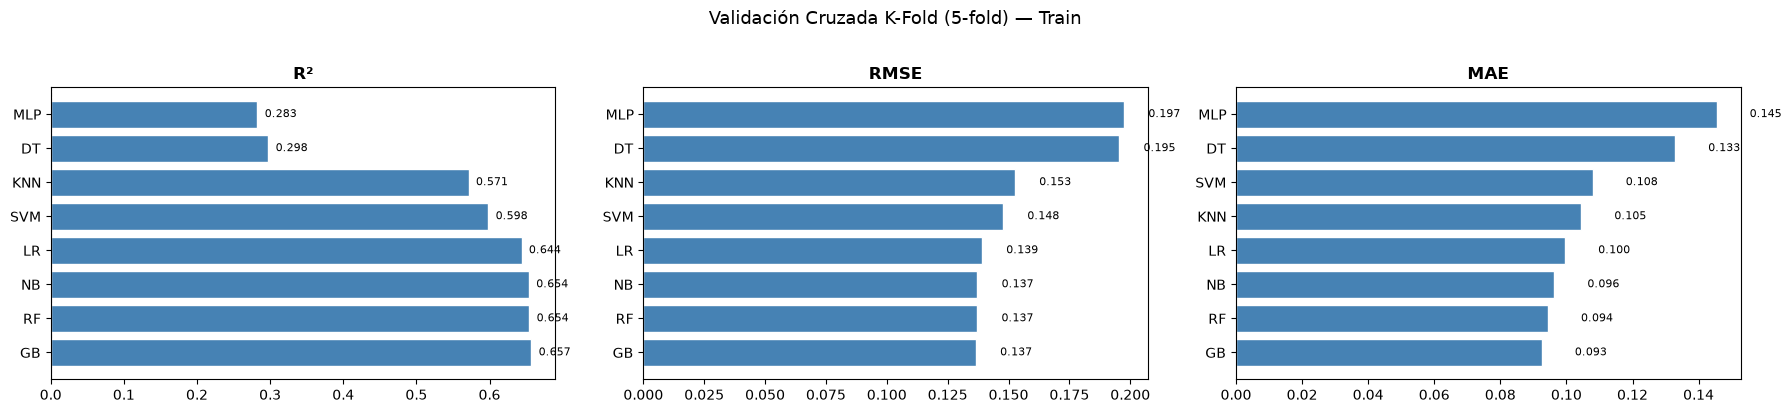

In [5]:
# Visualización de métricas CV
metric_labels = {'r2': 'R²', 'rmse': 'RMSE', 'mae': 'MAE'}
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, metric in zip(axes, cv_display_df.columns):
    vals = cv_display_df[metric].sort_values(ascending=(metric != 'r2'))
    bars = ax.barh(vals.index, vals.values, color='steelblue', edgecolor='white')
    ax.set_title(metric_labels[metric], fontweight='bold')
    if metric == 'r2':
        ax.axvline(0, ls='--', color='gray', lw=0.8)
    for bar, v in zip(bars, vals.values):
        offset = 0.01 if v >= 0 else -0.06
        ax.text(v + offset, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=8)
plt.suptitle('Validación Cruzada K-Fold (5-fold) — Train', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Evaluación sobre el Conjunto de Prueba

In [6]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Reentrenar cada modelo con el conjunto completo de entrenamiento
fitted_models = {}
test_results  = {}

for name, model in MODELS.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    y_pred_full = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred_full)
    test_results[name] = {
        'r2':   r2_score(y_test, y_pred_full),
        'mse':  mse,
        'rmse': np.sqrt(mse),
        'mae':  mean_absolute_error(y_test, y_pred_full),
    }

test_df_results = pd.DataFrame(test_results).T
test_df_results.index.name = 'Model'
test_df_results.sort_values('r2', ascending=False).round(4)

,r2,mse,rmse,mae
Model,,,,
NB,0.6496,0.0186,0.1364,0.0924
GB,0.6418,0.0190,0.1379,0.0876
LR,0.6415,0.0190,0.1379,0.0946
RF,0.6185,0.0202,0.1423,0.0939
SVM,0.5956,0.0215,0.1465,0.1051
KNN,0.5923,0.0216,0.1471,0.0960
MLP,0.4723,0.0280,0.1673,0.1217
DT,0.2977,0.0373,0.1930,0.1276


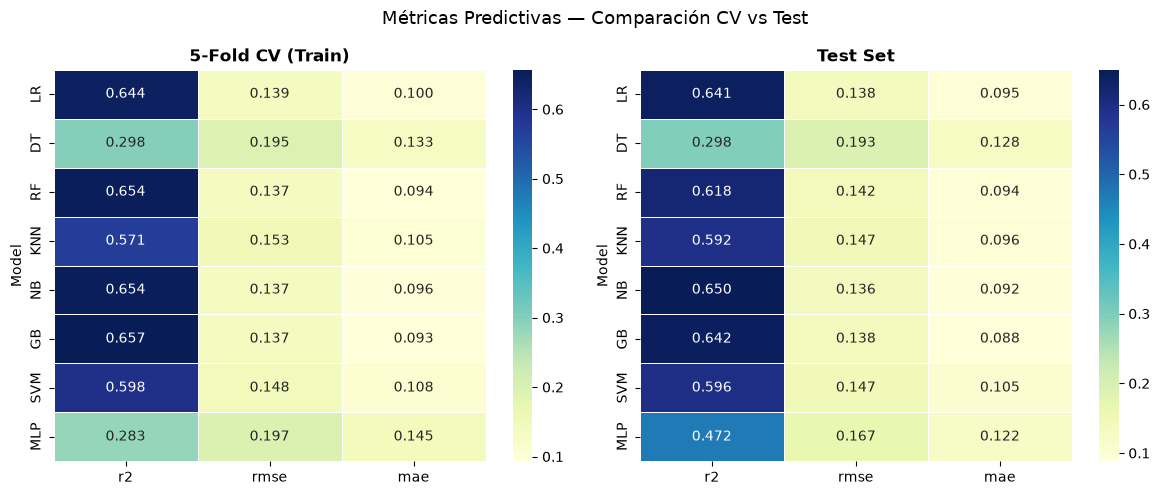

In [7]:
# Heatmap comparativo CV vs Test
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (df, title) in zip(axes, [
    (cv_display_df.round(3), '5-Fold CV (Train)'),
    (test_df_results[['r2', 'rmse', 'mae']].round(3), 'Test Set')
]):
    sns.heatmap(df, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Métricas Predictivas — Comparación CV vs Test', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Selección de los Mejores Modelos

Se seleccionan los modelos con mayor **R²** sobre el conjunto de prueba
(`RANK_BY='r2'`, orden descendente — mayor es mejor). Ajustá `TOP_N` según los
resultados.

In [8]:
# ── Parámetros de selección ───────────────────────────────────────────────────
RANK_BY = 'r2'   # métrica principal de ordenamiento (mayor = mejor)
TOP_N   = 3      # cantidad de modelos a seleccionar

ranked = test_df_results.sort_values(RANK_BY, ascending=False)
selected_names  = ranked.head(TOP_N).index.tolist()
selected_models = {n: fitted_models[n] for n in selected_names}

print(f"Modelos seleccionados para el análisis de explicabilidad:")
for i, name in enumerate(selected_names, 1):
    row = test_df_results.loc[name]
    print(f"  {i}. {name:5s} | R2={row['r2']:.3f}  RMSE={row['rmse']:.4f}  MAE={row['mae']:.4f}")

ranked.head(TOP_N).style.background_gradient(cmap='YlGn', axis=0)

Modelos seleccionados para el análisis de explicabilidad:
  1. NB    | R2=0.650  RMSE=0.1364  MAE=0.0924
  2. GB    | R2=0.642  RMSE=0.1379  MAE=0.0876
  3. LR    | R2=0.641  RMSE=0.1379  MAE=0.0946


,r2,mse,rmse,mae
Model,,,,
NB,0.649622,0.018593,0.136358,0.092401
GB,0.641768,0.019010,0.137877,0.087590
LR,0.641478,0.019026,0.137933,0.094607


### 5.1 Preparación de la muestra para el análisis de explicabilidad

El conjunto de test completo tiene 399 instancias × 101 features. KernelSHAP con
`nsamples ≈ 2·p + 16384` (la configuración que usa QSAR para sus modelos no
basados en árboles) es costoso de evaluar instancia por instancia, y correrlo
sobre las 399 filas para hasta 3 modelos sería demasiado lento en CPU local.
Siguiendo la misma escala que usa el propio notebook de QSAR para su sección de
XAI, subsampleamos aquí **80 instancias fijas** (sin reemplazo, `random_state=42`)
del conjunto de test para toda la sección de explicabilidad (SHAP, LIME,
RC/IS/GES, Bloques 1-3, bump chart de ranking y exportación a CSV). El
entrenamiento, la validación cruzada y la evaluación predictiva de las
Secciones 3-4 ya se hicieron sobre el conjunto de test **completo** (399 filas),
que es barato de computar y no necesita reducirse.

In [9]:
SAMPLE_SIZE_XAI = 80
np.random.seed(42)
xai_idx = np.random.choice(len(X_test), size=SAMPLE_SIZE_XAI, replace=False)

X_test_xai = X_test[xai_idx]
y_test_xai = y_test[xai_idx]

print(f"Subconjunto XAI: {X_test_xai.shape[0]} instancias x {X_test_xai.shape[1]} features")
print(f"(de un total de {X_test.shape[0]} instancias en el conjunto de test completo)")

Subconjunto XAI: 80 instancias x 101 features
(de un total de 399 instancias en el conjunto de test completo)


## 6. Generación de Explicaciones: SHAP y LIME

Para cada modelo seleccionado se generan las atribuciones locales de
características sobre la muestra de 80 instancias de test (`X_test_xai`).

**Diferencias frente a QSAR (clasificación → regresión):**
- `TreeExplainer.shap_values(...)` devuelve directamente un array 2D
  `(n_samples, n_features)` — no hay lista `[clase0, clase1]` que indexar.
- `KernelExplainer` envuelve `model.predict` (no `predict_proba`: los
  regresores no tienen ese método).
- `LimeTabularExplainer` usa `mode='regression'`, sin `class_names`; en el loop
  de explicación se llama `explain_instance(..., model.predict, ...)` sin el
  argumento `labels=(1,)`, y `exp.as_list()` sin `label=1`.

In [10]:
import shap
import lime
import lime.lime_tabular

# Diccionarios finales: model_name -> matriz (n_xai x n_features)
shap_attributions = {}
lime_attributions = {}

# ── LIME explainer (compartido, agnóstico al modelo) ─────────────────────────
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    mode='regression',
    discretize_continuous=False,    # Perturbaciones continuas → más fieles
    random_state=42
)

N_LIME_FEATURES = len(feature_names)   # explicar todas las features

tree_models = (RandomForestRegressor, GradientBoostingRegressor, DecisionTreeRegressor)

for name, model in selected_models.items():
    print(f"\n{'='*55}")
    print(f"  Modelo: {name}")
    print(f"{'='*55}")

    # ── SHAP ─────────────────────────────────────────────────────────────────
    print("  [SHAP] Calculando valores...")
    # Extraer el estimador final si el modelo es un Pipeline
    if hasattr(model, 'named_steps'):
        inner = model.named_steps[list(model.named_steps.keys())[-1]]
        steps_before_reg = list(model.named_steps.keys())[:-1]
        X_tr_transformed = X_train.copy()
        X_te_transformed = X_test_xai.copy()
        for step_name in steps_before_reg:
            X_tr_transformed = model.named_steps[step_name].transform(X_tr_transformed)
            X_te_transformed = model.named_steps[step_name].transform(X_te_transformed)
        predict_fn = model.predict
    else:
        inner = model
        X_tr_transformed = X_train
        X_te_transformed = X_test_xai
        predict_fn = model.predict

    # Elegir el explainer SHAP más adecuado según el tipo de modelo
    if isinstance(inner, tree_models):
        shap_exp = shap.TreeExplainer(inner)
        shap_vals = shap_exp.shap_values(X_te_transformed)
        # En regresión, TreeExplainer devuelve un array 2D directo: no hay
        # lista por clase que indexar (a diferencia de clasificación).
    else:
        # KernelSHAP: background resumido con k-means para velocidad
        N_KMEANS_CLUSTERS = min(50, len(X_tr_transformed))
        N_SAMPLES_SHAP    = 2 * len(feature_names) + 16384   # misma escala que QSAR

        background = shap.kmeans(X_tr_transformed, N_KMEANS_CLUSTERS)
        shap_exp   = shap.KernelExplainer(predict_fn, background)
        shap_vals  = shap_exp.shap_values(
            X_te_transformed,
            nsamples=N_SAMPLES_SHAP,
            l1_reg='auto'
        )
    shap_attributions[name] = shap_vals   # shape: (n_xai, n_features)
    print(f"  [SHAP] Listo. Shape: {shap_vals.shape}")

    # ── LIME ─────────────────────────────────────────────────────────────────
    print("  [LIME] Calculando explicaciones locales...")
    lime_matrix = np.zeros((len(X_test_xai), len(feature_names)))
    for i in range(len(X_test_xai)):
        exp = lime_explainer.explain_instance(
            X_test_xai[i],
            model.predict,
            num_features=N_LIME_FEATURES
        )
        # Mapear atribuciones de vuelta al orden original de features
        feat_map = dict(exp.as_list())
        for j, fname in enumerate(feature_names):
            matched = [v for k, v in feat_map.items() if fname in k]
            lime_matrix[i, j] = matched[0] if matched else 0.0

    lime_attributions[name] = lime_matrix
    print(f"  [LIME] Listo. Shape: {lime_matrix.shape}")

print("\n✅ Explicaciones generadas para todos los modelos.")


  Modelo: NB
  [SHAP] Calculando valores...


  0%|          | 0/80 [00:00<?, ?it/s]

  [SHAP] Listo. Shape: (80, 101)
  [LIME] Calculando explicaciones locales...


  [LIME] Listo. Shape: (80, 101)

  Modelo: GB
  [SHAP] Calculando valores...
  [SHAP] Listo. Shape: (80, 101)
  [LIME] Calculando explicaciones locales...


  [LIME] Listo. Shape: (80, 101)

  Modelo: LR
  [SHAP] Calculando valores...


  0%|          | 0/80 [00:00<?, ?it/s]

  [SHAP] Listo. Shape: (80, 101)
  [LIME] Calculando explicaciones locales...


  [LIME] Listo. Shape: (80, 101)

✅ Explicaciones generadas para todos los modelos.


### 6.1 Visualizaciones de las Explicaciones

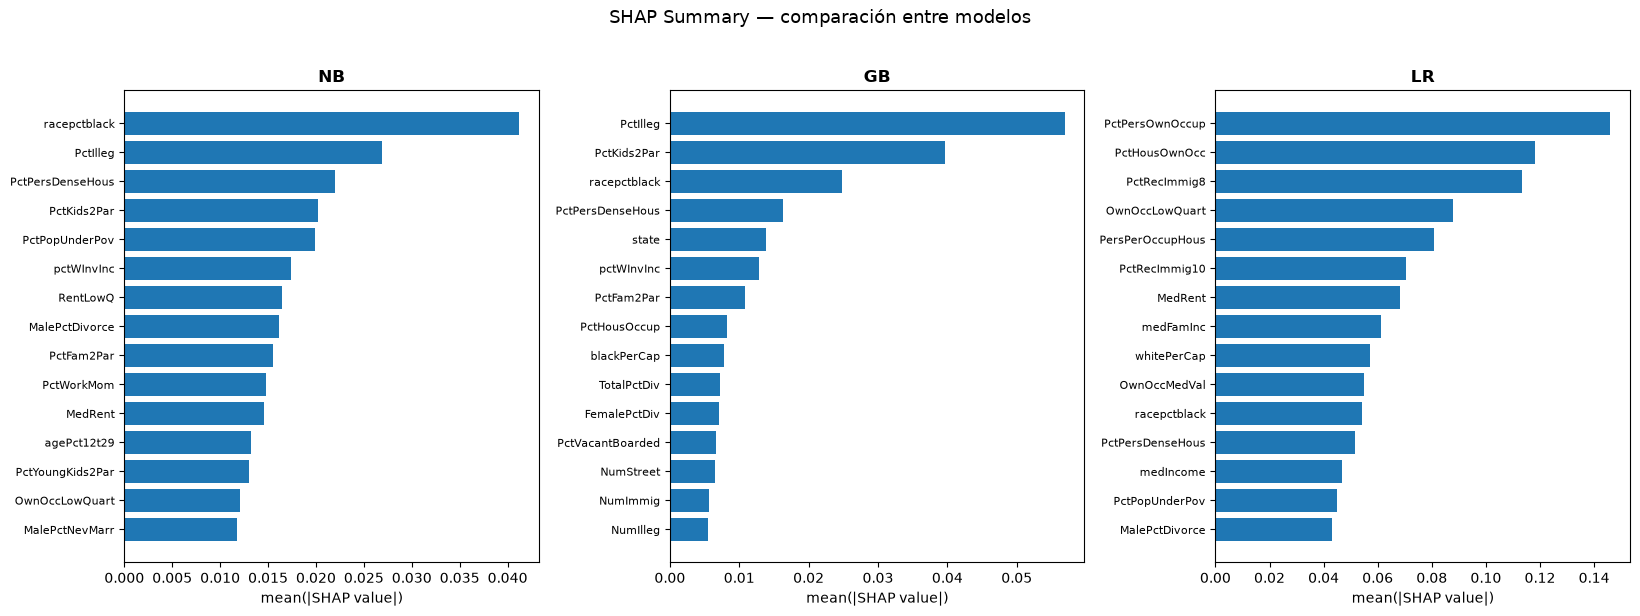

In [11]:
# ── SHAP summary plots (comparativo, una sola figura) ────────────────────────
N_DISPLAY = 15
n_models = len(selected_names)
fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 6))
if n_models == 1:
    axes = [axes]

for ax, name in zip(axes, selected_names):
    shap_vals_2d = shap_attributions[name]

    mean_abs_shap = np.abs(shap_vals_2d).mean(axis=0)
    order = np.argsort(mean_abs_shap)[-N_DISPLAY:]  # top N, ascendente para barh

    ax.barh([feature_names[i] for i in order], mean_abs_shap[order], color='#1f77b4')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('mean(|SHAP value|)')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('SHAP Summary — comparación entre modelos', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

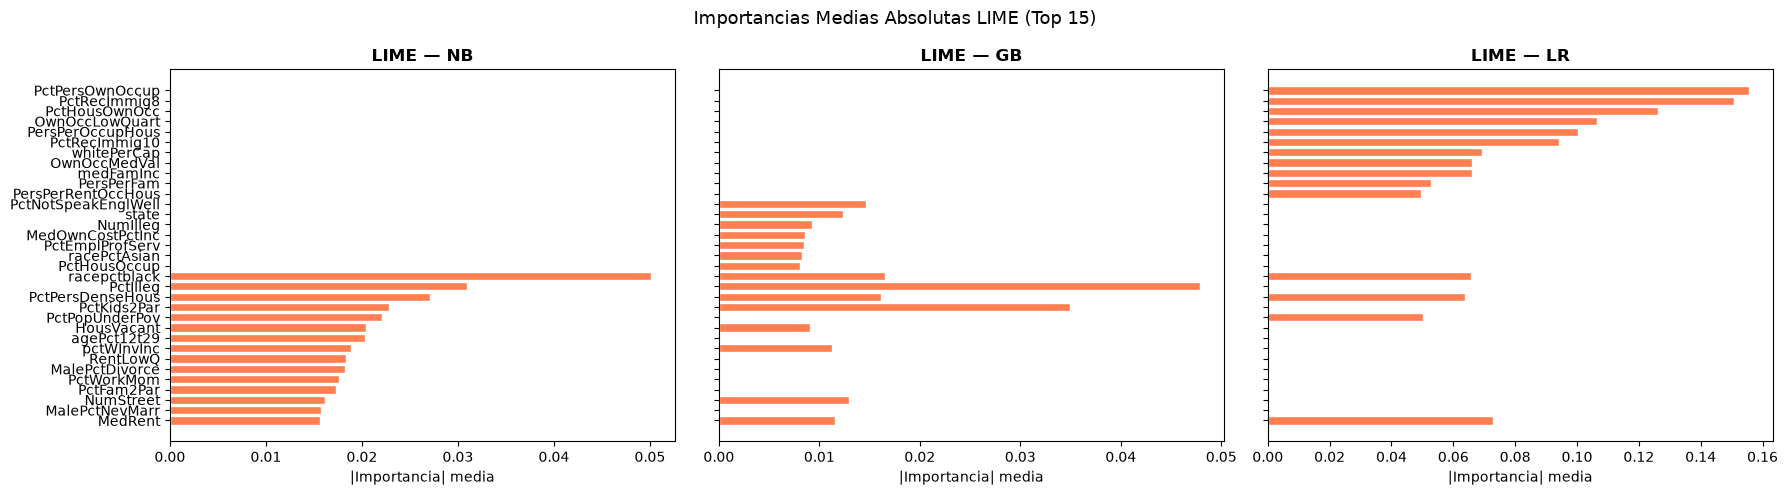

In [12]:
# ── LIME importancias medias absolutas ───────────────────────────────────────
fig, axes = plt.subplots(1, len(selected_names),
                         figsize=(6 * len(selected_names), 5),
                         sharey=True)
if len(selected_names) == 1:
    axes = [axes]

for ax, name in zip(axes, selected_names):
    mean_abs = np.abs(lime_attributions[name]).mean(axis=0)
    idx = np.argsort(mean_abs)[-15:]  # top 15
    ax.barh([feature_names[i] for i in idx], mean_abs[idx],
            color='coral', edgecolor='white')
    ax.set_title(f'LIME — {name}', fontweight='bold')
    ax.set_xlabel('|Importancia| media')

plt.suptitle('Importancias Medias Absolutas LIME (Top 15)', fontsize=13)
plt.tight_layout()
plt.show()

**Rank Consistency** — compara el ranking de cada instancia contra la **moda** del ranking de esa feature. La desviación se normaliza por el rango máximo posible (Ecs. 4-6, Muñoz et al. 2023):

$$r_{ij} = \text{rank}(f_{ij}), \qquad \text{mode}_j = \text{Mode}_i\{r_{ij}\}, \qquad D_{\max,j} = \max_i r_{ij} - \min_i r_{ij}$$
$$C_j = 1 - \frac{1}{M}\sum_{i=1}^{M} \frac{|r_{ij} - \text{mode}_j|}{D_{\max,j}}, \qquad R_C = \frac{1}{d}\sum_{j=1}^{d} C_j$$

**Importance Stability** — normaliza la varianza observada $V_j$ respecto a la varianza máxima teórica (cota de Bernoulli) (Ecs. 7-8, Muñoz et al. 2023):

$$\mu_j = \frac{1}{M}\sum_{i=1}^{M} f_{ij}, \qquad V_j = \frac{1}{M}\sum_{i=1}^{M}(f_{ij} - \mu_j)^2$$
$$S_j = 1 - \frac{V_j}{\mu_j(1 - \mu_j)}, \qquad IS = \frac{1}{d}\sum_{j=1}^{d} S_j$$

Ambas fórmulas promedian con el mismo peso entre las $d$ features, y $V_j$ es la varianza poblacional (divide por $M$).

## 7. Métricas HolisticAI — ecuaciones del paper (Muñoz et al. 2023)

Acá se implementan directamente las Ecuaciones (4)-(8) del paper *"Evaluating
Explainability in Machine Learning Predictions through Explainer-Agnostic
Metrics"* (Muñoz et al., arXiv:2302.12094), en vez de llamar a las funciones
tal cual están en el repo de holisticai.

Al revisar `_rank_consistency.py` y `_importance_stability.py` del
repositorio ([holisticai-research](https://github.com/holistic-ai/holisticai-research))
se detectó que ninguno de los dos reproduce exactamente lo que dice el
texto del paper:

- `rank_consistency()` devuelve $\bar D_j/D_{\max,j}$ crudo, sin el signo
  `1 -` de la Ec. 5 (por eso en la Figura 4 del paper el eje dice
  "1-Rank Consistency": los autores tuvieron que invertirlo para graficarlo).
- `importance_stability()` usa varianza muestral (`ddof=1`) en vez de la
  poblacional de la Ec. 7, promedia ponderando por importancia media en vez
  del promedio simple de la Ec. 8, y tampoco aplica el `1 -`.

Por eso abajo se reimplementan `rank_consistency_holistic` e
`importance_stability_holistic` a mano, siguiendo el texto del paper — **exactamente
las mismas funciones que en `0-QSAR_XAI_Notebook.ipynb`**, sin ningún cambio: son
agnósticas al tipo de tarea (clasificación o regresión), solo dependen de la
forma `(n_samples, n_features)` de la matriz de atribuciones.

Ambas métricas quedan en **[0, 1]**, con **1 = perfectamente consistente / estable**.

In [13]:
#   _rank_consistency.py       rank_consistency_holistic()        [Ecs. 4-6]
#   _importance_stability.py   importance_stability_holistic()    [Ecs. 7-8]

import numpy as np
from scipy import stats

EPSILON = 1e-8

# ── Rank Consistency (Ecs. 4-6 de Muñoz et al. 2023) ─────────────────────────
#El helper interno _local_normalized_deviation() (que calcula
# port fiel de local_normalized_desviation() de la librería._rank_consistency.py
def _local_normalized_deviation(local_importances_values: np.ndarray) -> np.ndarray:
    '''|r_ij - mode_j| / D_max,j por instancia y feature (Ec. 4).'''
    ranked_features = np.argsort(np.argsort(-local_importances_values, axis=1), axis=1)
    mode_result = stats.mode(ranked_features, axis=0, keepdims=False)
    return (np.abs(ranked_features - np.array(mode_result.mode)[None, :])) / (
        np.max(ranked_features, axis=0) - np.min(ranked_features, axis=0) + EPSILON
    )[None, :]


def rank_consistency_holistic(local_importances_values: np.ndarray,
                               weighted: bool = False) -> float:
    '''
    Implemento las Ecs. (4)-(6) del paper (Muñoz et al. 2023):

        C_j = 1 - D_bar_j / D_max,j          RC = (1/d) * sum_j C_j

    La función rank_consistency() del repo de holisticai devuelve
    D_bar_j/D_max,j crudo, sin el "1 -" de la Ec. 5 (me di cuenta
    comparando con las Tablas 1-2 del paper, que reportan justamente ese
    crudo con REF=0). Acá agrego el "1 -" para que 1 = consistencia
    perfecta, tal como está definido en el texto.

    Parameters
    ----------
    local_importances_values : np.ndarray, shape (n_samples, n_features)
    weighted : bool
        Si True, pondero por la importancia media absoluta normalizada
        (esto es una extensión de la librería, no está en la Ec. 6).

    Returns
    -------
    float en [0, 1]
    '''
    if local_importances_values.ndim == 3:
        local_importances_values = local_importances_values[:, :, 1]
    normalized_dev = _local_normalized_deviation(local_importances_values)
    consistencies  = np.mean(normalized_dev, axis=0)   # D_bar_j / D_max,j por feature
    if weighted:
        abs_vals = np.abs(local_importances_values)
        norm_vals = abs_vals / (abs_vals.sum(axis=1, keepdims=True) + EPSILON)
        avg_imp  = norm_vals.mean(axis=0)
        raw_score = np.sum(avg_imp * consistencies)
    else:
        raw_score = np.mean(consistencies)              # (1/d) * sum_j D_bar_j/D_max,j
    return float(1.0 - raw_score)                        # Ecs. 5-6


# ── Importance Stability (Ecs. 7-8 de Muñoz et al. 2023) ─────────────────────
def importance_stability_holistic(local_importances_values: np.ndarray) -> float:
    '''
    Implemento las Ecs. (7)-(8) del paper (Muñoz et al. 2023), a partir de
    importance_stability() del repo pero corrigiendo tres cosas que no
    coincidían con el texto:

        mu_j    = (1/M) * sum_i f_ij
        V_j     = (1/M) * sum_i (f_ij - mu_j)^2      <- varianza poblacional
        Vmax_j  = mu_j * (1 - mu_j)
        S_j     = 1 - V_j / Vmax_j                    <- con el signo "1 -"
        IS      = (1/d) * sum_j S_j                   <- promedio simple

    Lo que cambié respecto a `_importance_stability.py` del repo:
      1) ddof=0 (poblacional, 1/M) en vez de ddof=1 (muestral, 1/(M-1)).
      2) Agregué el "1 -" que la función original no tiene (mismo caso que
         rank_consistency: las Tablas 1-2 del paper reportan V_j/Vmax_j
         crudo, y por eso en la Figura 4 el eje dice "1-Importance
         Stability").
      3) Promedio simple (1/d) * sum_j S_j en vez del promedio ponderado
         por importancia media que trae la función original.

    Parameters
    ----------
    local_importances_values : np.ndarray, shape (n_samples, n_features)

    Returns
    -------
    float en [0, 1]  (1 = máxima estabilidad)
    '''
    if local_importances_values.ndim == 3:
        local_importances_values = local_importances_values[:, :, 1]

    row_sums = local_importances_values.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, EPSILON, row_sums)
    f = local_importances_values / row_sums            # normalizado a suma 1 por fila

    mu  = f.mean(axis=0)                                # mu_j, Ec. 7 (primera parte)
    var = f.var(axis=0, ddof=0)                         # V_j, Ec. 7 (segunda parte), poblacional

    d = f.shape[1]
    stabilities = np.empty(d)
    for j in range(d):
        if mu[j] <= 0 or mu[j] >= 1:
            ratio_j = 0.0    # Vmax_j = 0 -> caso degenerado, perfectamente estable
        else:
            vmax_j = mu[j] * (1 - mu[j])
            ratio_j = var[j] / vmax_j
        stabilities[j] = 1.0 - min(max(ratio_j, 0.0), 1.0)   # S_j, Ec. 8, clip a [0,1]

    return float(np.mean(stabilities))                  # IS, Ec. 8


# ── Calcular métricas HolisticAI (Ecs. del paper) para SHAP y LIME ───────────
print("Calculando métricas HolisticAI (Ecs. 4-8 del paper)...")
holistic_rows = []

for name in selected_names:
    for method, attr_dict in [('SHAP', shap_attributions),
                               ('LIME', lime_attributions)]:
        arr = attr_dict[name]                 # shape: (n_xai, n_features)
        if arr.ndim == 3:
            arr = arr[:, :, 1]  # clase positiva (dead branch en regresión)
        rc  = rank_consistency_holistic(arr)
        fs  = importance_stability_holistic(arr)
        ges = 0.5 * (rc + fs)
        holistic_rows.append({
            'Model': name, 'Explainer': method,
            'HC_RankConsistency': rc,
            'HC_FeatureStability': fs,
            'HC_GES': ges,
        })
        print(f"  {name:5s} | {method:4s} | "
              f"HC_RC={rc:.4f}  HC_FS={fs:.4f} HC_GES={ges:.4f}")

holistic_df = pd.DataFrame(holistic_rows)
print("\n✅ Métricas HolisticAI calculadas.")

Calculando métricas HolisticAI (Ecs. 4-8 del paper)...
  NB    | SHAP | HC_RC=0.6760  HC_FS=0.5577 HC_GES=0.6169
  NB    | LIME | HC_RC=0.9922  HC_FS=0.9999 HC_GES=0.9961
  GB    | SHAP | HC_RC=0.7402  HC_FS=0.5996 HC_GES=0.6699
  GB    | LIME | HC_RC=0.8177  HC_FS=0.8896 HC_GES=0.8537
  LR    | SHAP | HC_RC=0.6812  HC_FS=0.6015 HC_GES=0.6413
  LR    | LIME | HC_RC=0.9887  HC_FS=0.9816 HC_GES=0.9851

✅ Métricas HolisticAI calculadas.


## 8. Análisis Comparativo y Criterio de Selección

Se calcula para cada modelo:
- **∆RankConsistency** = |RC_SHAP − RC_LIME|
- **∆Stability** = |Stab_SHAP − Stab_LIME|
- **∆Global** = |GES_SHAP − GES_LIME|

In [14]:
print('Análisis Comparativo y Criterio de Selección HolisticAI')
comparison_rows = []
for name in selected_names:
    # Fetch metrics for SHAP from the holistic_df
    shap_m = holistic_df[(holistic_df.Model == name) &
                         (holistic_df.Explainer == 'SHAP')].iloc[0]
    # Fetch metrics for LIME from the holistic_df
    lime_m = holistic_df[(holistic_df.Model == name) &
                         (holistic_df.Explainer == 'LIME')].iloc[0]

    # Calculate deltas using HolisticAI metrics
    delta_rc  = abs(shap_m['HC_RankConsistency'] - lime_m['HC_RankConsistency'])
    delta_st  = abs(shap_m['HC_FeatureStability']       - lime_m['HC_FeatureStability'])
    delta_ges = abs(shap_m['HC_GES']             - lime_m['HC_GES'])

    # ── Criterio de selección ────────────────────────────────────────────────
    # Use HolisticAI metrics for comparison criteria
    shap_wins_rc = shap_m['HC_RankConsistency'] > lime_m['HC_RankConsistency']
    shap_wins_st = shap_m['HC_FeatureStability']       > lime_m['HC_FeatureStability']

    if shap_wins_rc and shap_wins_st:
        winner = 'SHAP'
        criterion = 'Dominancia'
    elif not shap_wins_rc and not shap_wins_st:
        winner = 'LIME'
        criterion = 'Dominancia'
    else:
        winner = 'SHAP' if shap_m['HC_GES'] >= lime_m['HC_GES'] else 'LIME'
        criterion = 'GES (trade-off)'

    comparison_rows.append({
        'Model':             name,
        # Append HolisticAI metrics to the comparison table
        'HC_RC_SHAP':           shap_m['HC_RankConsistency'],
        'HC_RC_LIME':           lime_m['HC_RankConsistency'],
        'HC_Stab_SHAP':         shap_m['HC_FeatureStability'],
        'HC_Stab_LIME':         lime_m['HC_FeatureStability'],
        'HC_GES_SHAP':          shap_m['HC_GES'],
        'HC_GES_LIME':          lime_m['HC_GES'],
        'HC_∆RankConsistency':  delta_rc,
        'HC_∆Stability':        delta_st,
        'HC_∆Global':           delta_ges,
        'HC_Winner':            winner,
        'HC_Criterion':         criterion,
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')
comparison_df.round(4)

Análisis Comparativo y Criterio de Selección HolisticAI


,HC_RC_SHAP,HC_RC_LIME,HC_Stab_SHAP,HC_Stab_LIME,HC_GES_SHAP,HC_GES_LIME,HC_∆RankConsistency,HC_∆Stability,HC_∆Global,HC_Winner,HC_Criterion
Model,,,,,,,,,,,
NB,0.6760,0.9922,0.5577,0.9999,0.6169,0.9961,0.3162,0.4423,0.3792,LIME,Dominancia
GB,0.7402,0.8177,0.5996,0.8896,0.6699,0.8537,0.0775,0.2900,0.1838,LIME,Dominancia
LR,0.6812,0.9887,0.6015,0.9816,0.6413,0.9851,0.3075,0.3801,0.3438,LIME,Dominancia


In [15]:
# ── Resumen de ganadores ──────────────────────────────────────────────────────
print("=" * 60)
print("RESUMEN: Método de explicabilidad preferido por modelo")
print("=" * 60)
for name, row in comparison_df.iterrows():
    print(f"  {name:5s} → {row['HC_Winner']:4s}  ({row['HC_Criterion']})")
    print(f"         SHAP: RC={row['HC_RC_SHAP']:.4f}  Stab={row['HC_Stab_SHAP']:.4f}  GES={row['HC_GES_SHAP']:.4f}")
    print(f"         LIME: RC={row['HC_RC_LIME']:.4f}  Stab={row['HC_Stab_LIME']:.4f}  GES={row['HC_GES_LIME']:.4f}")
    print(f"         Δ:   RC={row['HC_∆RankConsistency']:.4f}  Stab={row['HC_∆Stability']:.4f}  ΔGlobal={row['HC_∆Global']:.4f}")
    print()

RESUMEN: Método de explicabilidad preferido por modelo
  NB    → LIME  (Dominancia)
         SHAP: RC=0.6760  Stab=0.5577  GES=0.6169
         LIME: RC=0.9922  Stab=0.9999  GES=0.9961
         Δ:   RC=0.3162  Stab=0.4423  ΔGlobal=0.3792

  GB    → LIME  (Dominancia)
         SHAP: RC=0.7402  Stab=0.5996  GES=0.6699
         LIME: RC=0.8177  Stab=0.8896  GES=0.8537
         Δ:   RC=0.0775  Stab=0.2900  ΔGlobal=0.1838

  LR    → LIME  (Dominancia)
         SHAP: RC=0.6812  Stab=0.6015  GES=0.6413
         LIME: RC=0.9887  Stab=0.9816  GES=0.9851
         Δ:   RC=0.3075  Stab=0.3801  ΔGlobal=0.3438



### 8.1 Visualización del Análisis Comparativo

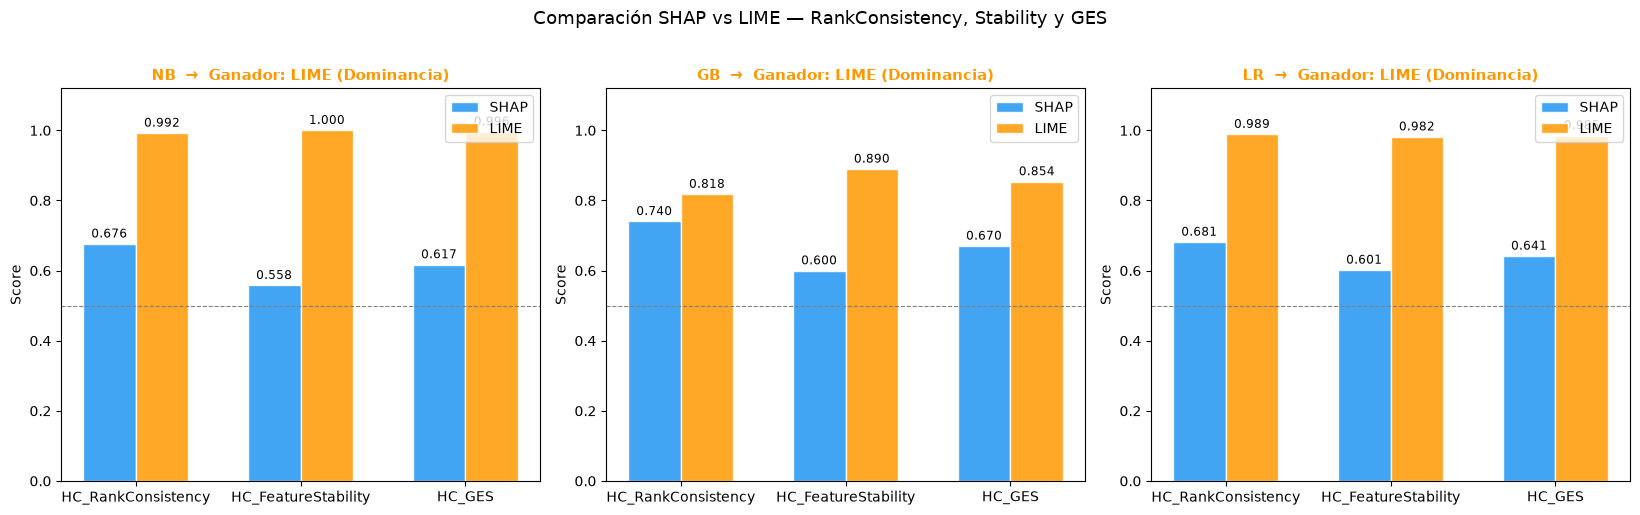

In [16]:
n_models = len(selected_names)
fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 5))
if n_models == 1:
    axes = [axes]

colors = {'SHAP': '#2196F3', 'LIME': '#FF9800'}
metrics_to_plot = ['HC_RankConsistency', 'HC_FeatureStability', 'HC_GES']

for ax, name in zip(axes, selected_names):
    x = np.arange(len(metrics_to_plot))
    w = 0.32
    for offset, method in zip([-w/2, w/2], ['SHAP', 'LIME']):
        row = holistic_df[(holistic_df.Model == name) &
                          (holistic_df.Explainer == method)].iloc[0]
        vals = [row[m] for m in metrics_to_plot]
        bars = ax.bar(x + offset, vals, w, label=method,
                      color=colors[method], edgecolor='white', alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8.5)

    winner = comparison_df.loc[name, 'HC_Winner']
    criterion = comparison_df.loc[name, 'HC_Criterion']
    ax.set_title(f'{name}  →  Ganador: {winner} ({criterion})',
                 fontsize=11, fontweight='bold',
                 color=colors[winner])
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_to_plot, fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score')
    ax.axhline(0.5, ls='--', lw=0.8, color='gray')
    ax.legend()

plt.suptitle('Comparación SHAP vs LIME — RankConsistency, Stability y GES',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

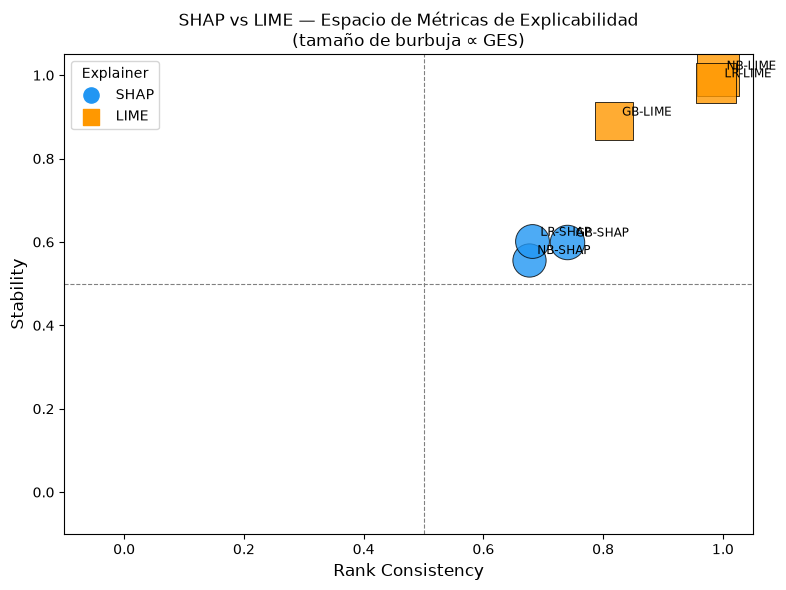

In [17]:
# ── Scatter: Stability vs Rank Consistency (bubble = GES) ────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
markers = {'SHAP': 'o', 'LIME': 's'}

for _, row in holistic_df.iterrows():
    c = colors[row['Explainer']]
    sc = ax.scatter(row['HC_RankConsistency'], row['HC_FeatureStability'],
                    s=row['HC_GES'] * 800 + 80,
                    color=c, marker=markers[row['Explainer']],
                    alpha=0.8, edgecolors='k', linewidths=0.7)
    ax.annotate(f"{row['Model']}-{row['Explainer']}",
                xy=(row['HC_RankConsistency'], row['HC_FeatureStability']),
                xytext=(6, 4), textcoords='offset points', fontsize=8.5)

# Leyenda manual
for method, marker in markers.items():
    ax.scatter([], [], s=120, color=colors[method], marker=marker, label=method)
ax.legend(title='Explainer', fontsize=10)

ax.axhline(0.5, ls='--', lw=0.8, color='gray')
ax.axvline(0.5, ls='--', lw=0.8, color='gray')
ax.set_xlabel('Rank Consistency', fontsize=12)
ax.set_ylabel('Stability', fontsize=12)
ax.set_title('SHAP vs LIME — Espacio de Métricas de Explicabilidad\n'
             '(tamaño de burbuja ∝ GES)', fontsize=12)
ax.set_xlim(-0.1, 1.05)
ax.set_ylim(-0.1, 1.05)
plt.tight_layout()
plt.show()

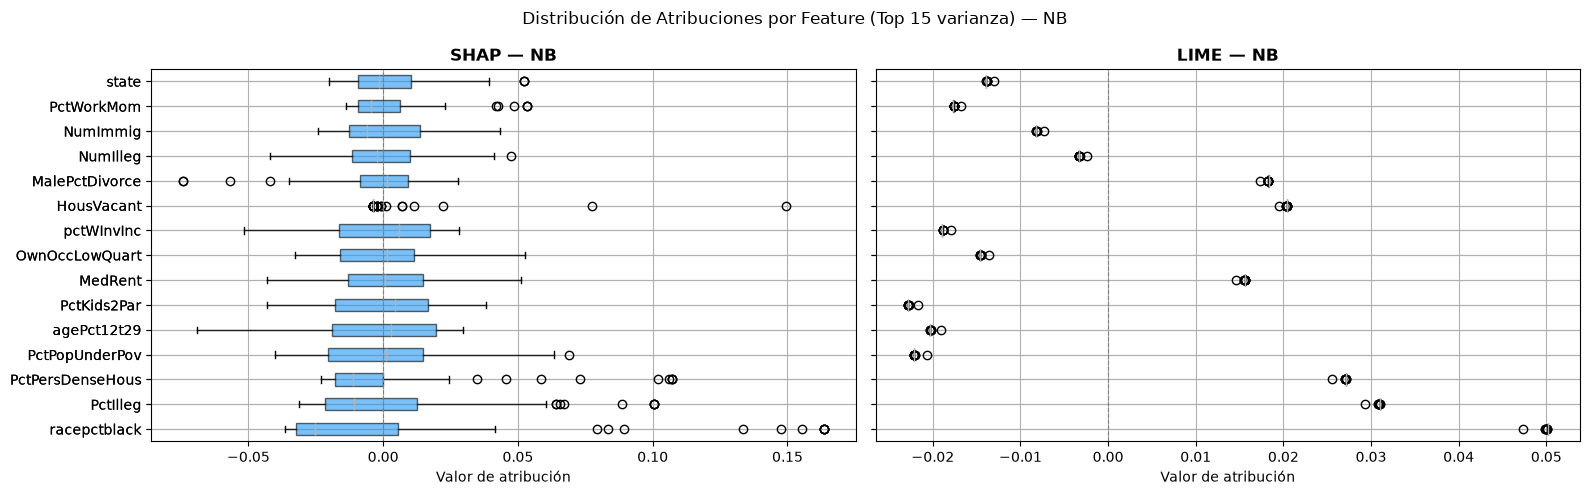

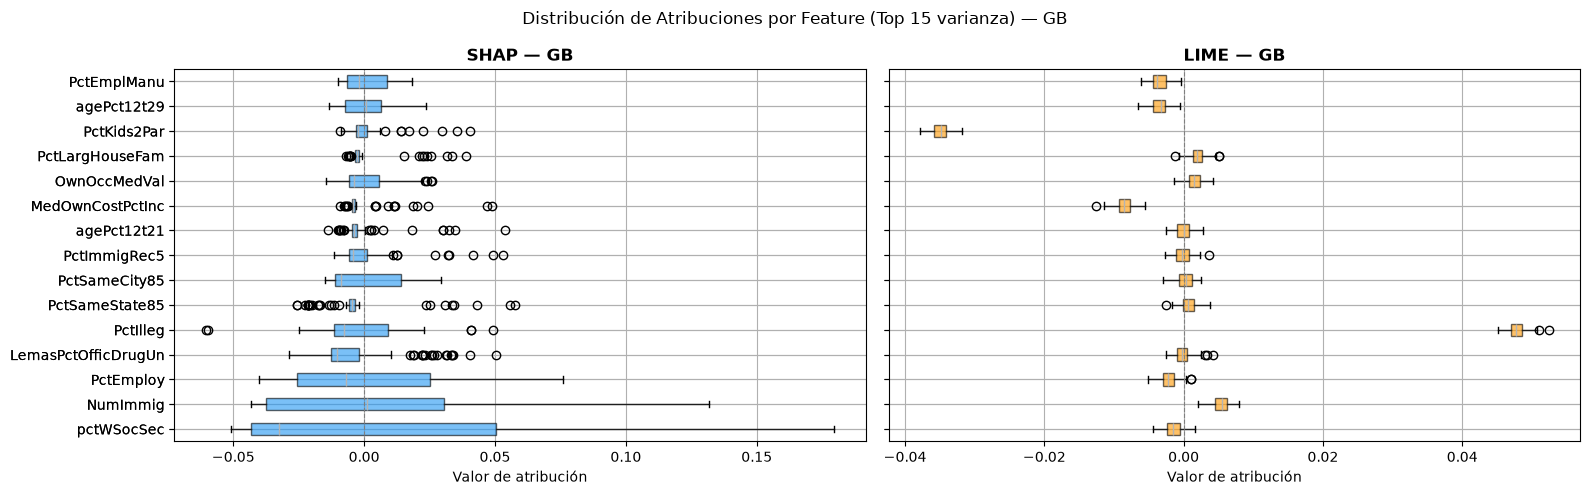

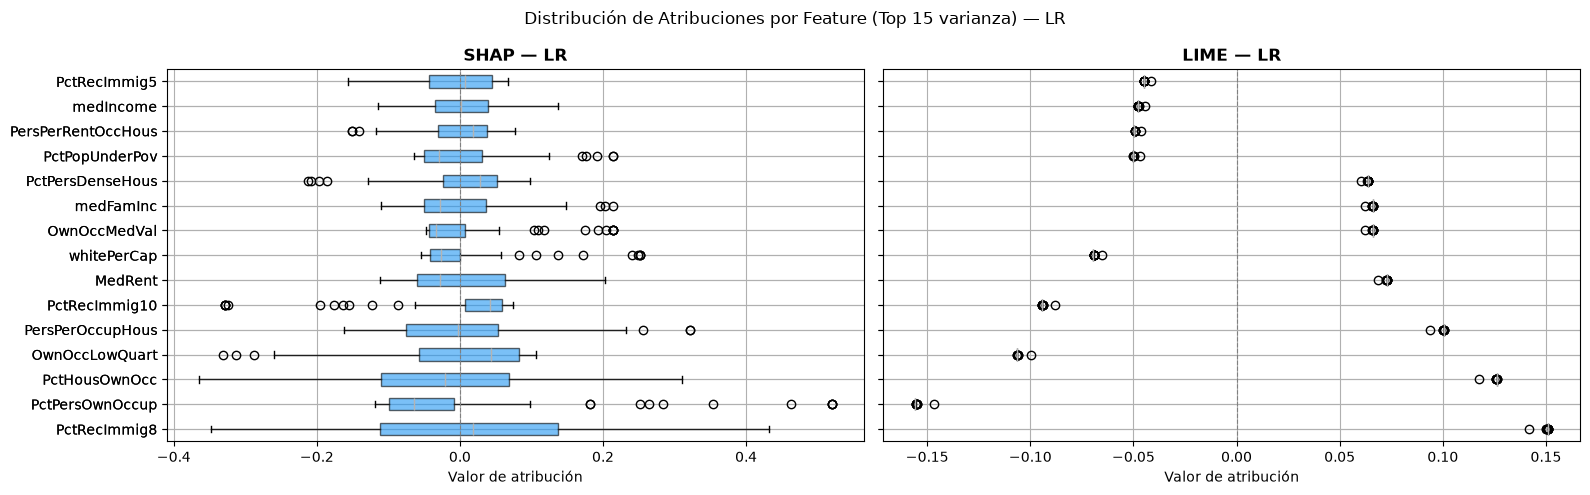

In [18]:
# ── Estabilidad por feature (boxplots SHAP vs LIME) ──────────────────────────
for name in selected_names:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    for ax, (method, attr) in zip(axes,
        [('SHAP', shap_attributions[name]),
         ('LIME', lime_attributions[name])]):

        df_box = pd.DataFrame(attr, columns=feature_names)
        order = df_box.std().sort_values(ascending=False).index[:15]
        df_box[order].boxplot(ax=ax, vert=False,
                               patch_artist=True,
                               boxprops=dict(facecolor=colors[method], alpha=0.6))
        ax.set_title(f'{method} — {name}', fontweight='bold')
        ax.set_xlabel('Valor de atribución')
        ax.axvline(0, ls='--', lw=0.8, color='gray')

    plt.suptitle(f'Distribución de Atribuciones por Feature (Top 15 varianza) — {name}',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

### 8.2 Diferencias ∆ entre métodos

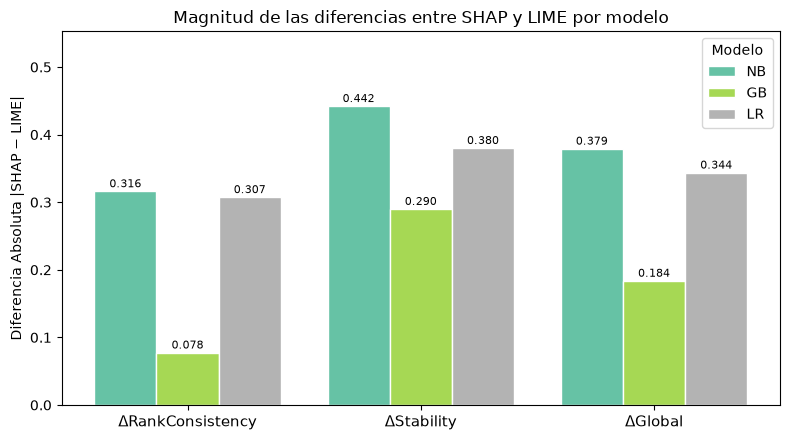

In [19]:
delta_cols = ['HC_∆RankConsistency', 'HC_∆Stability', 'HC_∆Global']
delta_data = comparison_df[delta_cols].copy()

fig, ax = plt.subplots(figsize=(8, max(3, n_models * 1.5)))
x = np.arange(len(delta_cols))
w = 0.8 / n_models
palette = plt.cm.Set2(np.linspace(0, 1, n_models))

for i, (name, row) in enumerate(delta_data.iterrows()):
    offset = (i - n_models / 2 + 0.5) * w
    bars = ax.bar(x + offset, row.values, w,
                  label=name, color=palette[i], edgecolor='white')
    for bar, v in zip(bars, row.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['ΔRankConsistency', 'ΔStability', 'ΔGlobal'], fontsize=11)
ax.set_ylabel('Diferencia Absoluta |SHAP − LIME|')
ax.set_title('Magnitud de las diferencias entre SHAP y LIME por modelo', fontsize=12)
ax.legend(title='Modelo')
ax.set_ylim(0, max(delta_data.values.max() * 1.25, 0.1))
plt.tight_layout()
plt.show()

## 9. Conclusión Final

In [20]:
print("╔" + "═" * 62 + "╗")
print("║   CONCLUSIÓN: Selección del Método de Explicabilidad        ║")
print("╠" + "═" * 62 + "╣")
for name, row in comparison_df.iterrows():
    gap = 62 - len(name) - len(row['HC_Winner']) - len(row['HC_Criterion']) - 14
    print(f"║  Modelo {name}:  {row['HC_Winner']} es preferido  [{row['HC_Criterion']}]{' ' * max(0, gap)}║")
print("╠" + "═" * 62 + "╣")

# Ganador global por GES medio
ges_shap = comparison_df['HC_GES_SHAP'].mean()
ges_lime = comparison_df['HC_GES_LIME'].mean()
global_winner = 'SHAP' if ges_shap >= ges_lime else 'LIME'
print(f"║  GES medio global — SHAP: {ges_shap:.4f} | LIME: {ges_lime:.4f}       ║")
print(f"║  ➤  Método preferido globalmente: {global_winner:4s}                   ║")
print("╚" + "═" * 62 + "╝")

╔══════════════════════════════════════════════════════════════╗
║   CONCLUSIÓN: Selección del Método de Explicabilidad        ║
╠══════════════════════════════════════════════════════════════╣
║  Modelo NB:  LIME es preferido  [Dominancia]                                ║
║  Modelo GB:  LIME es preferido  [Dominancia]                                ║
║  Modelo LR:  LIME es preferido  [Dominancia]                                ║
╠══════════════════════════════════════════════════════════════╣
║  GES medio global — SHAP: 0.6427 | LIME: 0.9450       ║
║  ➤  Método preferido globalmente: LIME                   ║
╚══════════════════════════════════════════════════════════════╝


---
## Referencias

- Munoz, C., da Costa, K., Modenesi, B., & Koshiyama, A. (2023). *Evaluating explainability in machine learning predictions through explainer-agnostic metrics*. arXiv:2302.12094.
- Redmond, M. (2009). *Communities and Crime Data Set*. UCI Machine Learning Repository.
- Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. *NeurIPS*.
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). 'Why should I trust you?': Explaining the predictions of any classifier. *KDD*.

---
## Bloque 1 — Casos de mayor desacuerdo SHAP vs LIME

Para cada instancia de la muestra XAI, calcular la distancia entre los rankings
de ambos métodos (tau de Kendall). Mostrar las top-K instancias donde más
discrepan, junto con:

- Los valores reales de sus features
- Las atribuciones de cada método lado a lado
- Qué tan grande fue el error de predicción del modelo en esa instancia

La conjetura explorable (versión regresión): ¿los desacuerdos ocurren más en
instancias donde el modelo comete **mayor error** (peor ajuste, análogo a la
"frontera de decisión" en clasificación)? ¿O en comunidades atípicas (outliers
en el espacio de features)?

In [21]:
## Celda 1 — Setup del análisis cualitativo
# ── Setup Bloque 1 ──────────────────────────────────────────────────────────
from scipy.stats import kendalltau
from scipy.spatial.distance import cdist

# Usamos el primer modelo seleccionado como caso de estudio principal
# Podés cambiar MODEL_FOCUS a cualquiera de selected_names
MODEL_FOCUS = selected_names[0]

shap_attr = shap_attributions[MODEL_FOCUS]
lime_attr = lime_attributions[MODEL_FOCUS]

n_test = len(X_test_xai)
model  = fitted_models[MODEL_FOCUS]
y_pred = model.predict(X_test_xai)          # predicción continua (no hay predict_proba)
abs_error = np.abs(y_pred - y_test_xai)
large_error = abs_error > np.percentile(abs_error, 75)   # análogo a "erróneo": top 25% de error

print(f"Modelo de análisis: {MODEL_FOCUS}")
print(f"Instancias (muestra XAI): {n_test}  |  Error alto (top 25%): {large_error.sum()}  |  Resto: {(~large_error).sum()}")

Modelo de análisis: NB
Instancias (muestra XAI): 80  |  Error alto (top 25%): 20  |  Resto: 60


Top instancias con mayor desacuerdo SHAP vs LIME
────────────────────────────────────────────────────────────
  #1  inst= 66 | distancia=1.447 | y_real=0.240 | y_pred=0.305 | error_abs=0.065 | ok
  #2  inst= 22 | distancia=1.418 | y_real=0.010 | y_pred=0.146 | error_abs=0.136 | ⚠ error alto
  #3  inst= 19 | distancia=1.416 | y_real=0.090 | y_pred=0.185 | error_abs=0.095 | ok
  #4  inst= 55 | distancia=1.399 | y_real=0.150 | y_pred=0.103 | error_abs=0.047 | ok
  #5  inst= 60 | distancia=1.396 | y_real=0.060 | y_pred=0.185 | error_abs=0.125 | ⚠ error alto


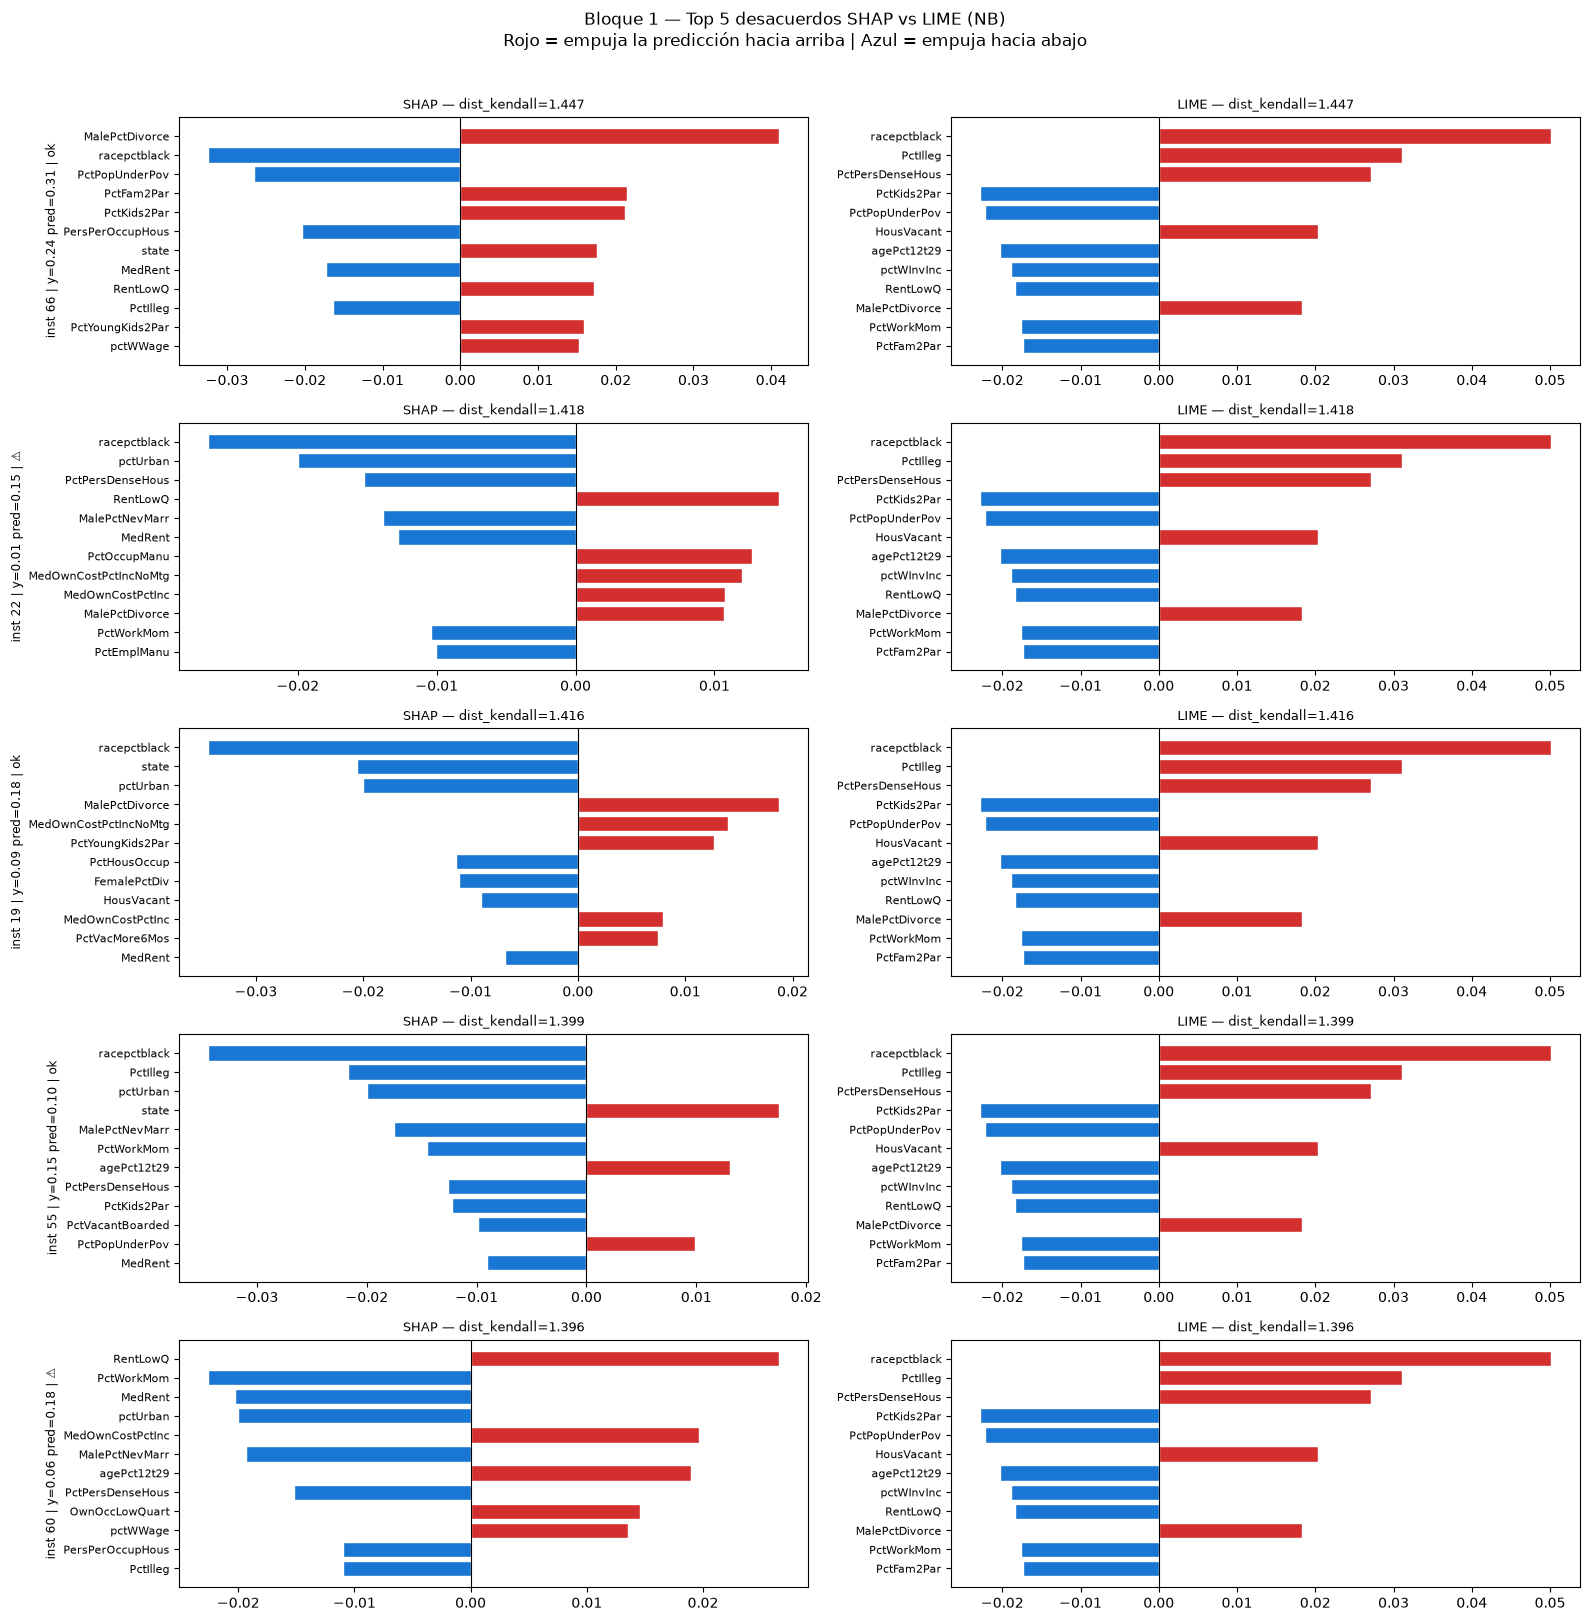

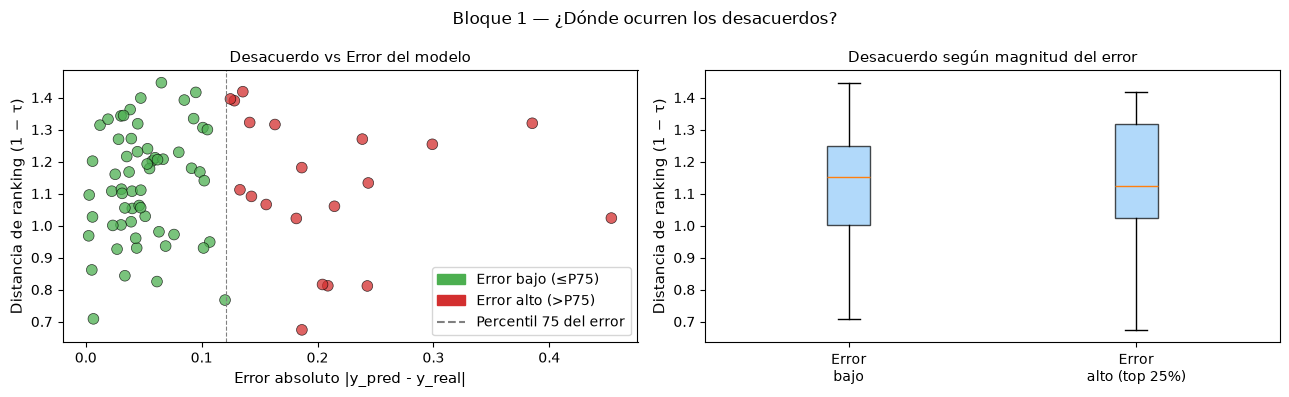


CONJETURA — Bloque 1
  Correlación error absoluto vs desacuerdo: -0.023
  Desacuerdo medio en instancias de mayor error (top 25%): 1.125  (n=20)
  Desacuerdo medio en instancias de menor error:            1.130  (n=60)


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 1 — Instancias con mayor desacuerdo entre SHAP y LIME
# ══════════════════════════════════════════════════════════════════════════════
#Celda 2 — Bloque 1: Casos de mayor desacuerdo SHAP vs LIME

from scipy.stats import rankdata, kendalltau

# Calcular distancia de ranking (1 - tau de Kendall) para cada instancia
kendall_distances = []
for i in range(n_test):
    tau, _ = kendalltau(shap_attr[i], lime_attr[i])
    kendall_distances.append(1 - tau)   # 0 = acuerdo total, 2 = desacuerdo total

kendall_distances = np.array(kendall_distances)
TOP_K = 5
top_idx = np.argsort(kendall_distances)[::-1][:TOP_K]

print("Top instancias con mayor desacuerdo SHAP vs LIME")
print("─" * 60)
for rank, i in enumerate(top_idx, 1):
    print(f"  #{rank}  inst={i:3d} | distancia={kendall_distances[i]:.3f} | "
          f"y_real={y_test_xai[i]:.3f} | y_pred={y_pred[i]:.3f} | "
          f"error_abs={abs_error[i]:.3f} | {'⚠ error alto' if large_error[i] else 'ok'}")

# ── Visualización: atribuciones lado a lado para cada caso top ─────────────
fig, axes = plt.subplots(TOP_K, 2, figsize=(16, TOP_K * 3.2))
for row, i in enumerate(top_idx):
    for col, (method, attr) in enumerate([('SHAP', shap_attr), ('LIME', lime_attr)]):
        ax = axes[row, col]
        vals = attr[i]
        idx_sorted = np.argsort(np.abs(vals))[-12:]
        colors_bar = ['#d32f2f' if v > 0 else '#1976d2' for v in vals[idx_sorted]]
        ax.barh([feature_names[k] for k in idx_sorted], vals[idx_sorted],
                color=colors_bar, edgecolor='white')
        ax.axvline(0, color='k', lw=0.8)
        if col == 0:
            status = f"inst {i} | y={y_test_xai[i]:.2f} pred={y_pred[i]:.2f} | {'⚠' if large_error[i] else 'ok'}"
            ax.set_ylabel(status, fontsize=8.5)
        ax.set_title(f"{method} — dist_kendall={kendall_distances[i]:.3f}", fontsize=9)
        ax.tick_params(axis='y', labelsize=8)

plt.suptitle(f'Bloque 1 — Top {TOP_K} desacuerdos SHAP vs LIME ({MODEL_FOCUS})\n'
             f'Rojo = empuja la predicción hacia arriba | Azul = empuja hacia abajo',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── ¿Los desacuerdos ocurren en instancias de mayor error? ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(abs_error, kendall_distances,
                c=['#d32f2f' if e else '#4caf50' for e in large_error],
                alpha=0.75, edgecolors='k', linewidths=0.5, s=60)
axes[0].axvline(np.percentile(abs_error, 75), ls='--', color='gray', lw=0.8, label='percentil 75 error')
axes[0].set_xlabel('Error absoluto |y_pred - y_real|', fontsize=11)
axes[0].set_ylabel('Distancia de ranking (1 − τ)', fontsize=11)
axes[0].set_title('Desacuerdo vs Error del modelo', fontsize=11)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#4caf50', label='Error bajo (≤P75)'),
                          Patch(color='#d32f2f', label='Error alto (>P75)'),
                          plt.Line2D([0],[0], ls='--', color='gray', label='Percentil 75 del error')])

# Boxplot: desacuerdo según error bajo/alto
data_low  = kendall_distances[~large_error]
data_high = kendall_distances[large_error]
axes[1].boxplot([data_low, data_high],
                tick_labels=['Error\nbajo', 'Error\nalto (top 25%)'],
                patch_artist=True,
                boxprops=dict(facecolor='#90caf9', alpha=0.7))
axes[1].set_ylabel('Distancia de ranking (1 − τ)', fontsize=11)
axes[1].set_title('Desacuerdo según magnitud del error', fontsize=11)

plt.suptitle('Bloque 1 — ¿Dónde ocurren los desacuerdos?', fontsize=12)
plt.tight_layout()
plt.show()

# ── Conjetura ─────────────────────────────────────────────────────────────────
corr_err = np.corrcoef(abs_error, kendall_distances)[0, 1]
print("\nCONJETURA — Bloque 1")
print(f"  Correlación error absoluto vs desacuerdo: {corr_err:.3f}")
print(f"  Desacuerdo medio en instancias de mayor error (top 25%): "
      f"{data_high.mean():.3f}  (n={large_error.sum()})")
print(f"  Desacuerdo medio en instancias de menor error:            "
      f"{data_low.mean():.3f}  (n={(~large_error).sum()})")

---
## Bloque 2 — Inestabilidad local: ¿dónde falla cada método?
Calcular la contribución de cada instancia a la métrica de Stability (su
varianza individual respecto a la media). Identificar las instancias que más
"arrastran" la inestabilidad de SHAP vs las de LIME. Cruzar eso con:

- Distancia al centroide del training set (¿son instancias lejanas al dominio?)
- Error de predicción del modelo (¿son las instancias peor predichas?)

La conjetura explorable: LIME perturba localmente con datos sintéticos, entonces
puede ser más inestable en regiones de baja densidad de datos. SHAP usa el
background global, entonces puede fallar más en instancias donde la interacción
entre features es atípica.

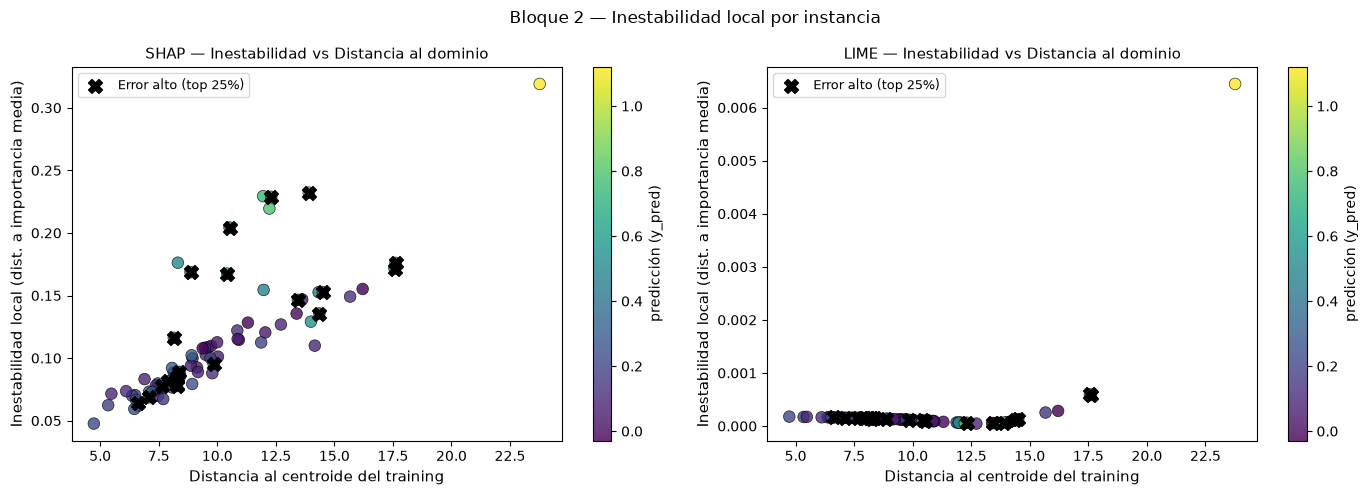

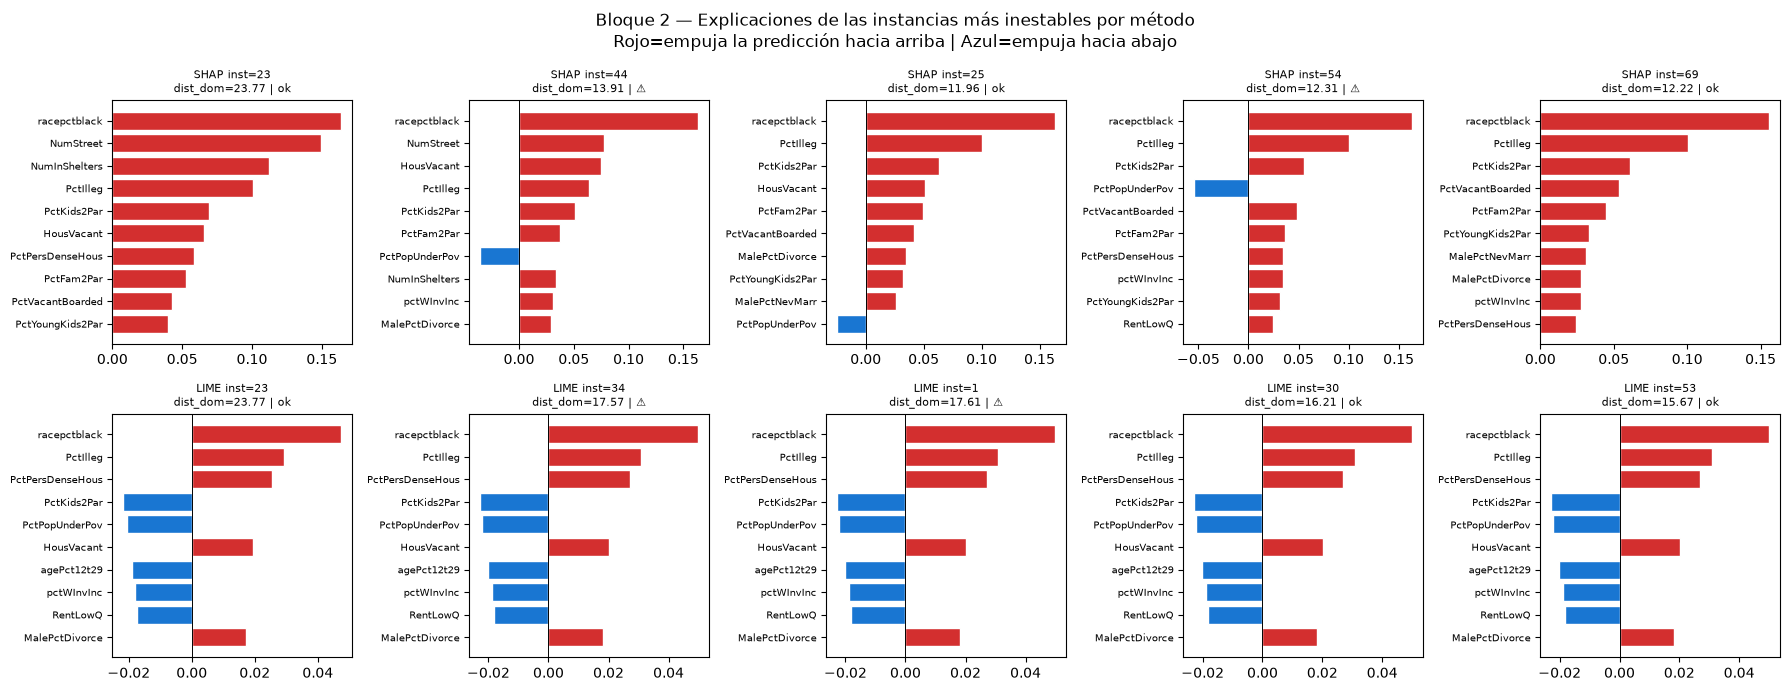

CONJETURA — Bloque 2
  Correlación (distancia al dominio vs inestabilidad):
    SHAP: 0.803  |  LIME: 0.494
  Correlación (error absoluto vs inestabilidad):
    SHAP: 0.388  |  LIME: 0.062

  Instancias lejanas al dominio (Q3=11.89, n=20):
    Inestabilidad SHAP: 0.170  vs cercanas: 0.093
    Inestabilidad LIME: 0.000  vs cercanas: 0.000


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 2 — ¿Dónde falla cada método? Inestabilidad local vs dominio
# ══════════════════════════════════════════════════════════════════════════════
#Celda 3 — Bloque 2: Inestabilidad local y distancia al dominio

# Contribución de cada instancia a la inestabilidad (varianza local)
def local_instability(attr_matrix):
    '''Distancia L2 de cada instancia a la importancia media.'''
    mean_attr = attr_matrix.mean(axis=0)
    return np.linalg.norm(attr_matrix - mean_attr, axis=1)

instab_shap = local_instability(shap_attr)
instab_lime = local_instability(lime_attr)

# Distancia de cada instancia de test (muestra XAI) al centroide del entrenamiento
centroid_train = X_train.mean(axis=0)
dist_to_domain = np.linalg.norm(X_test_xai - centroid_train, axis=1)

# ── Visualización principal ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (method, instab) in zip(axes, [('SHAP', instab_shap), ('LIME', instab_lime)]):
    sc = ax.scatter(dist_to_domain, instab,
                    c=y_pred, cmap='viridis',
                    alpha=0.8, edgecolors='k', linewidths=0.5, s=70)
    # Marcar instancias de error alto con X
    ax.scatter(dist_to_domain[large_error], instab[large_error],
               marker='X', color='black', s=100, zorder=5, label='Error alto (top 25%)')
    plt.colorbar(sc, ax=ax, label='predicción (y_pred)')
    ax.set_xlabel('Distancia al centroide del training', fontsize=11)
    ax.set_ylabel('Inestabilidad local (dist. a importancia media)', fontsize=11)
    ax.set_title(f'{method} — Inestabilidad vs Distancia al dominio', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Bloque 2 — Inestabilidad local por instancia', fontsize=12)
plt.tight_layout()
plt.show()

# ── Instancias más inestables de cada método ──────────────────────────────────
TOP_INSTAB = 5
fig, axes = plt.subplots(2, TOP_INSTAB, figsize=(18, 7))
for row, (method, instab, attr) in enumerate([
        ('SHAP', instab_shap, shap_attr),
        ('LIME', instab_lime, lime_attr)]):
    top_inst = np.argsort(instab)[::-1][:TOP_INSTAB]
    for col, i in enumerate(top_inst):
        ax = axes[row, col]
        vals = attr[i]
        idx_s = np.argsort(np.abs(vals))[-10:]
        bar_colors = ['#d32f2f' if v > 0 else '#1976d2' for v in vals[idx_s]]
        ax.barh([feature_names[k] for k in idx_s], vals[idx_s],
                color=bar_colors, edgecolor='white')
        ax.axvline(0, color='k', lw=0.7)
        ax.set_title(
            f"{method} inst={i}\n"
            f"dist_dom={dist_to_domain[i]:.2f} | "
            f"{'⚠' if large_error[i] else 'ok'}",
            fontsize=8)
        ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Bloque 2 — Explicaciones de las instancias más inestables por método\n'
             'Rojo=empuja la predicción hacia arriba | Azul=empuja hacia abajo', fontsize=12)
plt.tight_layout()
plt.show()

# ── Correlaciones y conjetura ──────────────────────────────────────────────────
corr_shap = np.corrcoef(dist_to_domain, instab_shap)[0, 1]
corr_lime = np.corrcoef(dist_to_domain, instab_lime)[0, 1]
corr_shap_err = np.corrcoef(abs_error, instab_shap)[0, 1]
corr_lime_err = np.corrcoef(abs_error, instab_lime)[0, 1]

print("CONJETURA — Bloque 2")
print(f"  Correlación (distancia al dominio vs inestabilidad):")
print(f"    SHAP: {corr_shap:.3f}  |  LIME: {corr_lime:.3f}")
print(f"  Correlación (error absoluto vs inestabilidad):")
print(f"    SHAP: {corr_shap_err:.3f}  |  LIME: {corr_lime_err:.3f}")
print()
q3 = np.percentile(dist_to_domain, 75)
far_mask = dist_to_domain > q3
print(f"  Instancias lejanas al dominio (Q3={q3:.2f}, n={far_mask.sum()}):")
print(f"    Inestabilidad SHAP: {instab_shap[far_mask].mean():.3f}  "
      f"vs cercanas: {instab_shap[~far_mask].mean():.3f}")
print(f"    Inestabilidad LIME: {instab_lime[far_mask].mean():.3f}  "
      f"vs cercanas: {instab_lime[~far_mask].mean():.3f}")

## Bloque 3 — Análisis de features "conflictivas"
Para cada feature, calcular cuántas veces SHAP y LIME difieren en el signo de la
atribución (una dice que empuja la predicción hacia arriba, la otra hacia
abajo). Mostrar un heatmap instancias × features con los conflictos de signo.
Elegir 2-3 features con más conflictos y graficar su distribución de valores en
train vs las instancias conflictivas.

La conjetura explorable: los conflictos de signo podrían concentrarse en
features con distribución bimodal o con interacciones no lineales fuertes con
otras features, donde la linealización local de LIME y la marginalización de
SHAP llevan a interpretaciones opuestas.

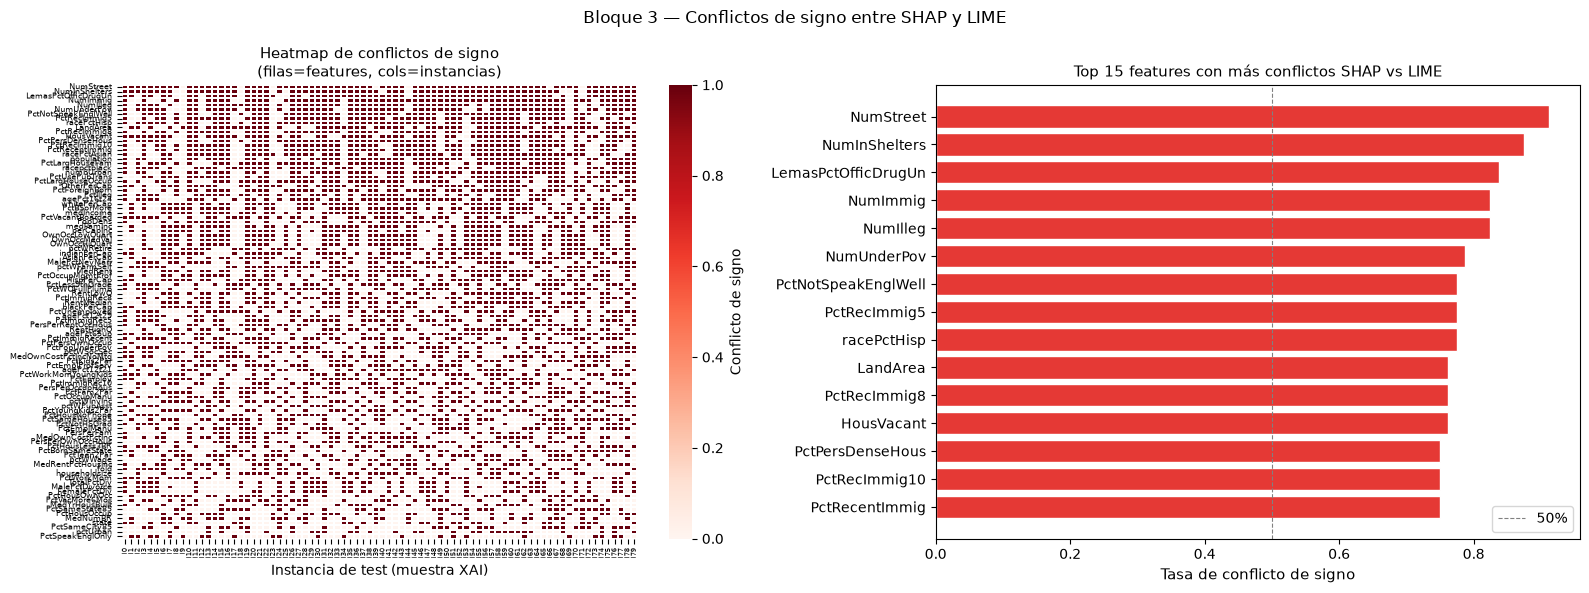

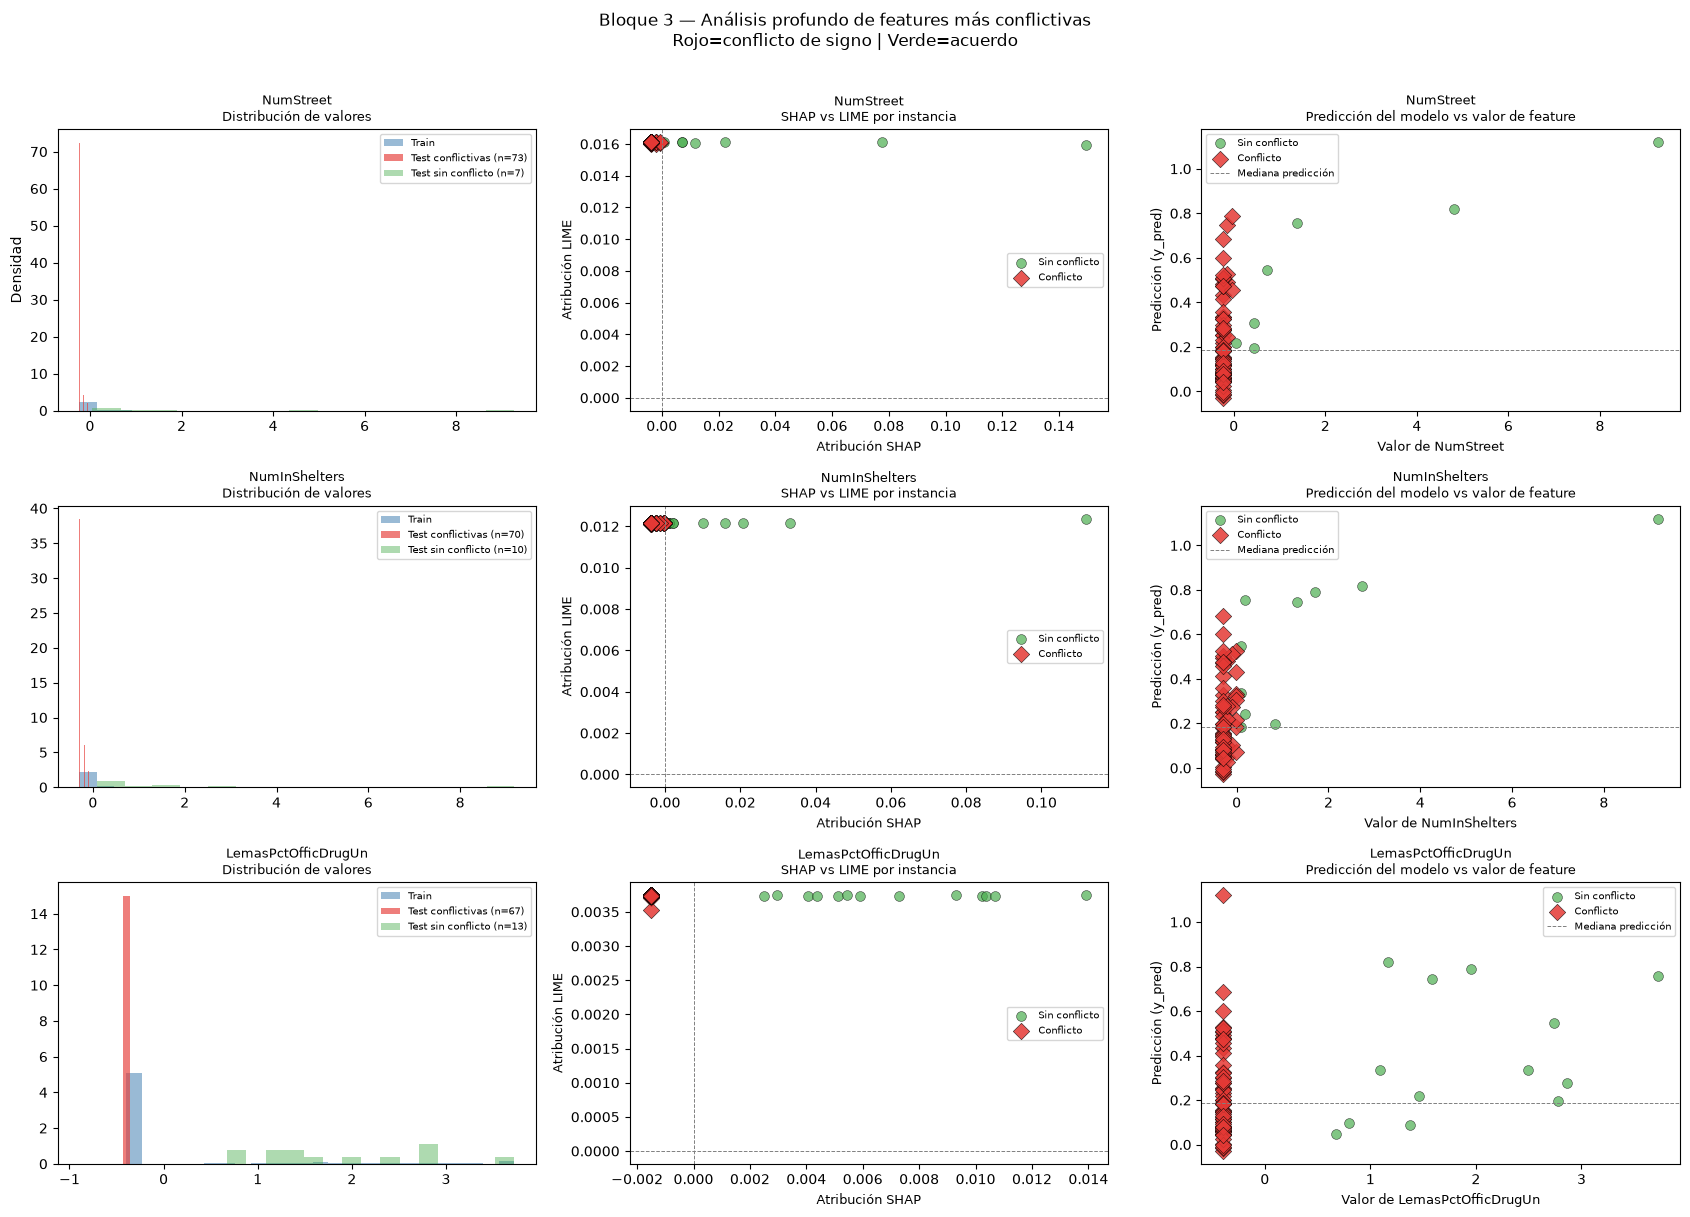

CONJETURA — Bloque 3

  Feature: NumStreet  (conflicto en 73/80 instancias)
    Valor medio train:        -0.0000  ±1.0000
    Valor medio conflictivas: -0.2210  ±0.0371
    Desplazamiento (z-score): 0.221
    predicción media conflictivas: 0.224  (error alto en 18 de esas instancias)

  Feature: NumInShelters  (conflicto en 70/80 instancias)
    Valor medio train:        -0.0000  ±1.0000
    Valor medio conflictivas: -0.2429  ±0.0957
    Desplazamiento (z-score): 0.243
    predicción media conflictivas: 0.208  (error alto en 18 de esas instancias)

  Feature: LemasPctOfficDrugUn  (conflicto en 67/80 instancias)
    Valor medio train:        0.0000  ±1.0000
    Valor medio conflictivas: -0.3949  ±0.0000
    Desplazamiento (z-score): 0.395
    predicción media conflictivas: 0.224  (error alto en 17 de esas instancias)


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 3 — Features con conflictos de signo entre SHAP y LIME
# ══════════════════════════════════════════════════════════════════════════════
#Celda 4 — Bloque 3: Features con conflictos de signo

# Conflicto de signo: SHAP y LIME tienen signo opuesto (excluyendo ceros)
sign_shap = np.sign(shap_attr)
sign_lime = np.sign(lime_attr)

# Conflicto = signos opuestos y ninguno es cero
conflict_matrix = (sign_shap * sign_lime) < 0   # shape (n_xai, n_features)
conflict_rate   = conflict_matrix.mean(axis=0)   # por feature

# ── Heatmap instancias × features ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ordenar features por tasa de conflicto
feat_order = np.argsort(conflict_rate)[::-1]
feat_labels = [feature_names[i] for i in feat_order]

sns.heatmap(conflict_matrix[:, feat_order].T.astype(int),
            ax=axes[0],
            cmap='Reds', cbar_kws={'label': 'Conflicto de signo'},
            xticklabels=[f"i{i}" for i in range(n_test)],
            yticklabels=feat_labels,
            linewidths=0.2)
axes[0].set_title('Heatmap de conflictos de signo\n(filas=features, cols=instancias)',
                  fontsize=11)
axes[0].set_xlabel('Instancia de test (muestra XAI)')
axes[0].tick_params(axis='y', labelsize=6)
axes[0].tick_params(axis='x', labelsize=5)

# Barplot: tasa de conflicto por feature (top 15)
top15_feat = feat_order[:15]
axes[1].barh([feature_names[i] for i in top15_feat[::-1]],
             conflict_rate[top15_feat[::-1]],
             color='#e53935', edgecolor='white')
axes[1].set_xlabel('Tasa de conflicto de signo', fontsize=11)
axes[1].set_title('Top 15 features con más conflictos SHAP vs LIME', fontsize=11)
axes[1].axvline(0.5, ls='--', color='gray', lw=0.8, label='50%')
axes[1].legend()

plt.suptitle('Bloque 3 — Conflictos de signo entre SHAP y LIME', fontsize=12)
plt.tight_layout()
plt.show()

# ── Análisis profundo: top 3 features conflictivas ────────────────────────────
TOP_FEAT = 3
top_conflict_features = feat_order[:TOP_FEAT]
median_pred = np.median(y_pred)

fig, axes = plt.subplots(TOP_FEAT, 3, figsize=(17, TOP_FEAT * 4))

for row, fi in enumerate(top_conflict_features):
    fname = feature_names[fi]
    conflict_mask = conflict_matrix[:, fi]

    # Col 0: distribución del valor de la feature en train vs instancias conflictivas
    ax = axes[row, 0]
    ax.hist(X_train[:, fi], bins=25, alpha=0.55, color='steelblue',
            density=True, label='Train')
    ax.hist(X_test_xai[conflict_mask, fi], bins=15, alpha=0.65, color='#e53935',
            density=True, label=f'Test conflictivas (n={conflict_mask.sum()})')
    ax.hist(X_test_xai[~conflict_mask, fi], bins=15, alpha=0.45, color='#4caf50',
            density=True, label=f'Test sin conflicto (n={(~conflict_mask).sum()})')
    ax.set_title(f'{fname}\nDistribución de valores', fontsize=9)
    ax.legend(fontsize=7)
    ax.set_ylabel(f'Densidad' if row == 0 else '')

    # Col 1: atribuciones SHAP y LIME para esta feature, coloreadas por conflicto
    ax = axes[row, 1]
    ax.scatter(shap_attr[~conflict_mask, fi], lime_attr[~conflict_mask, fi],
               color='#4caf50', alpha=0.7, s=50, label='Sin conflicto', edgecolors='k', lw=0.4)
    ax.scatter(shap_attr[conflict_mask, fi], lime_attr[conflict_mask, fi],
               color='#e53935', alpha=0.85, s=70, label='Conflicto', edgecolors='k', lw=0.4,
               marker='D')
    ax.axhline(0, color='gray', lw=0.7, ls='--')
    ax.axvline(0, color='gray', lw=0.7, ls='--')
    ax.set_xlabel('Atribución SHAP', fontsize=9)
    ax.set_ylabel('Atribución LIME', fontsize=9)
    ax.set_title(f'{fname}\nSHAP vs LIME por instancia', fontsize=9)
    ax.legend(fontsize=7)

    # Col 2: ¿los conflictos se relacionan con la predicción del modelo?
    ax = axes[row, 2]
    ax.scatter(X_test_xai[~conflict_mask, fi], y_pred[~conflict_mask],
               color='#4caf50', alpha=0.7, s=50, label='Sin conflicto', edgecolors='k', lw=0.4)
    ax.scatter(X_test_xai[conflict_mask, fi], y_pred[conflict_mask],
               color='#e53935', alpha=0.85, s=70, label='Conflicto', edgecolors='k', lw=0.4,
               marker='D')
    ax.axhline(median_pred, color='gray', lw=0.7, ls='--', label='Mediana predicción')
    ax.set_xlabel(f'Valor de {fname}', fontsize=9)
    ax.set_ylabel('Predicción (y_pred)', fontsize=9)
    ax.set_title(f'{fname}\nPredicción del modelo vs valor de feature', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Bloque 3 — Análisis profundo de features más conflictivas\n'
             'Rojo=conflicto de signo | Verde=acuerdo', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── Conjetura ─────────────────────────────────────────────────────────────────
print("CONJETURA — Bloque 3")
for fi in top_conflict_features:
    fname = feature_names[fi]
    conflict_mask = conflict_matrix[:, fi]
    vals_conflict  = X_test_xai[conflict_mask, fi]
    vals_no_conflict = X_test_xai[~conflict_mask, fi]
    vals_train = X_train[:, fi]

    # Bimodalidad aproximada: diferencia entre media de train y de conflictivas
    shift = abs(vals_conflict.mean() - vals_train.mean()) / (vals_train.std() + 1e-9)
    print(f"\n  Feature: {fname}  (conflicto en {conflict_mask.sum()}/{n_test} instancias)")
    print(f"    Valor medio train:        {vals_train.mean():.4f}  ±{vals_train.std():.4f}")
    print(f"    Valor medio conflictivas: {vals_conflict.mean():.4f}  ±{vals_conflict.std():.4f}")
    print(f"    Desplazamiento (z-score): {shift:.3f}")
    print(f"    predicción media conflictivas: {y_pred[conflict_mask].mean():.3f}  "
          f"(error alto en {(large_error[conflict_mask]).sum()} de esas instancias)")

---
## Gráfico de Ranking de Features

La tabla de abajo tiene todas las features (101 en este dataset) con su
importancia media absoluta según SHAP y LIME, su posición en el ranking de cada
método, y `rank_diff` (cuántas posiciones sube o baja una feature entre los dos
métodos) — las diferencias grandes son los mismos conflictos que salieron en el
Bloque 3.

El bump chart del panel derecho sirve para ver eso mismo de forma visual: cada
línea es una feature, y las rojas son las que más cambian de posición entre
SHAP y LIME.


  Modelo: NB — Ranking completo de features (top 20 por SHAP)
         Feature  SHAP_mean_abs  LIME_mean_abs  SHAP_rank  LIME_rank  rank_diff
    racepctblack       0.041208       0.050107          1          1          0
        PctIlleg       0.026870       0.030987          2          2          0
PctPersDenseHous       0.021941       0.027119          3          3          0
     PctKids2Par       0.020205       0.022846          4          4          0
  PctPopUnderPov       0.019857       0.022143          5          5          0
      pctWInvInc       0.017349       0.018892          6          8         -2
        RentLowQ       0.016497       0.018316          7          9         -2
  MalePctDivorce       0.016155       0.018286          8         10         -2
      PctFam2Par       0.015523       0.017277          9         12         -3
      PctWorkMom       0.014733       0.017621         10         11         -1
         MedRent       0.014625       0.015587         11

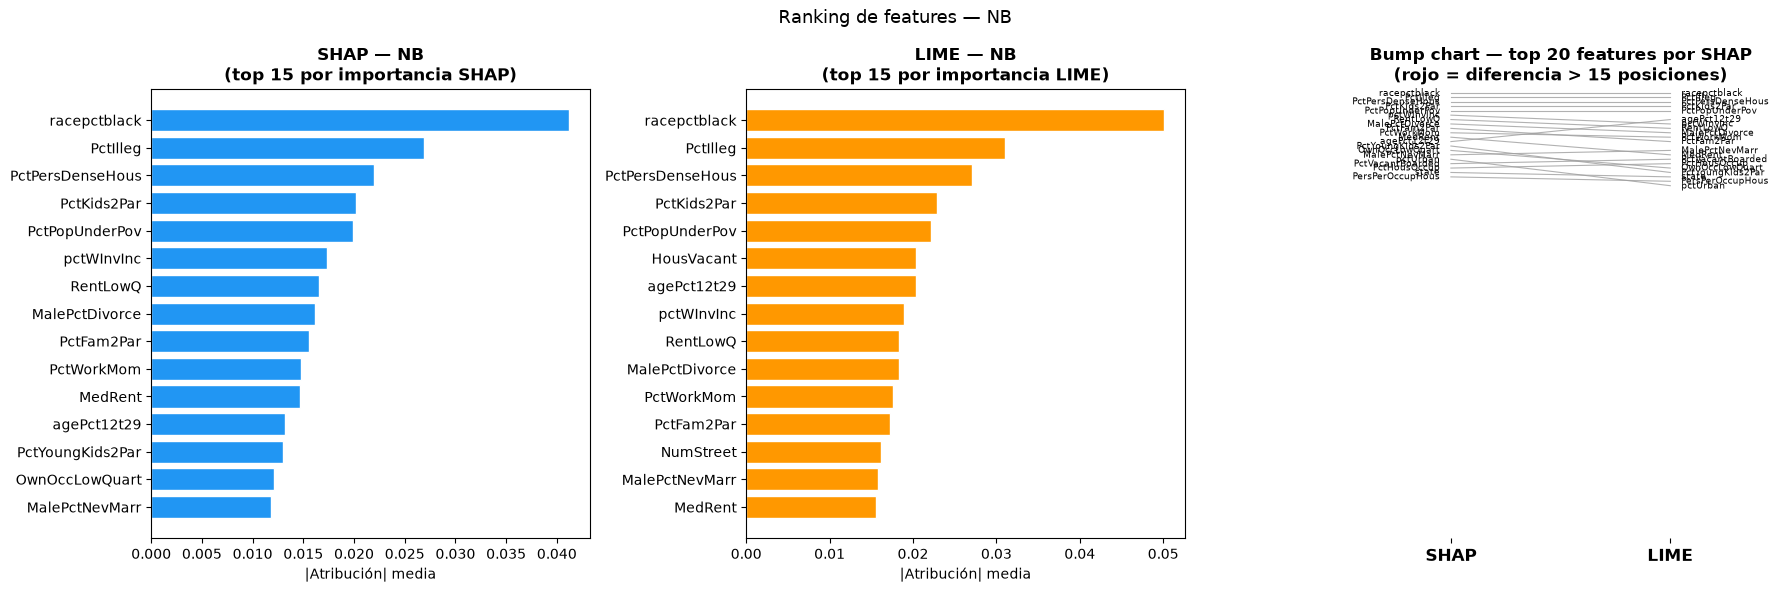


  Modelo: GB — Ranking completo de features (top 20 por SHAP)
         Feature  SHAP_mean_abs  LIME_mean_abs  SHAP_rank  LIME_rank  rank_diff
        PctIlleg       0.056913       0.047871          1          1          0
     PctKids2Par       0.039723       0.034985          2          2          0
    racepctblack       0.024805       0.016553          3          3          0
PctPersDenseHous       0.016304       0.016169          4          4          0
           state       0.013829       0.012336          5          7         -2
      pctWInvInc       0.012894       0.011219          6          9         -3
      PctFam2Par       0.010812       0.002889          7         41        -34
    PctHousOccup       0.008238       0.008033          8         15         -7
     blackPerCap       0.007766       0.002023          9         50        -41
     TotalPctDiv       0.007297       0.007058         10         16         -6
    FemalePctDiv       0.007057       0.006811         11

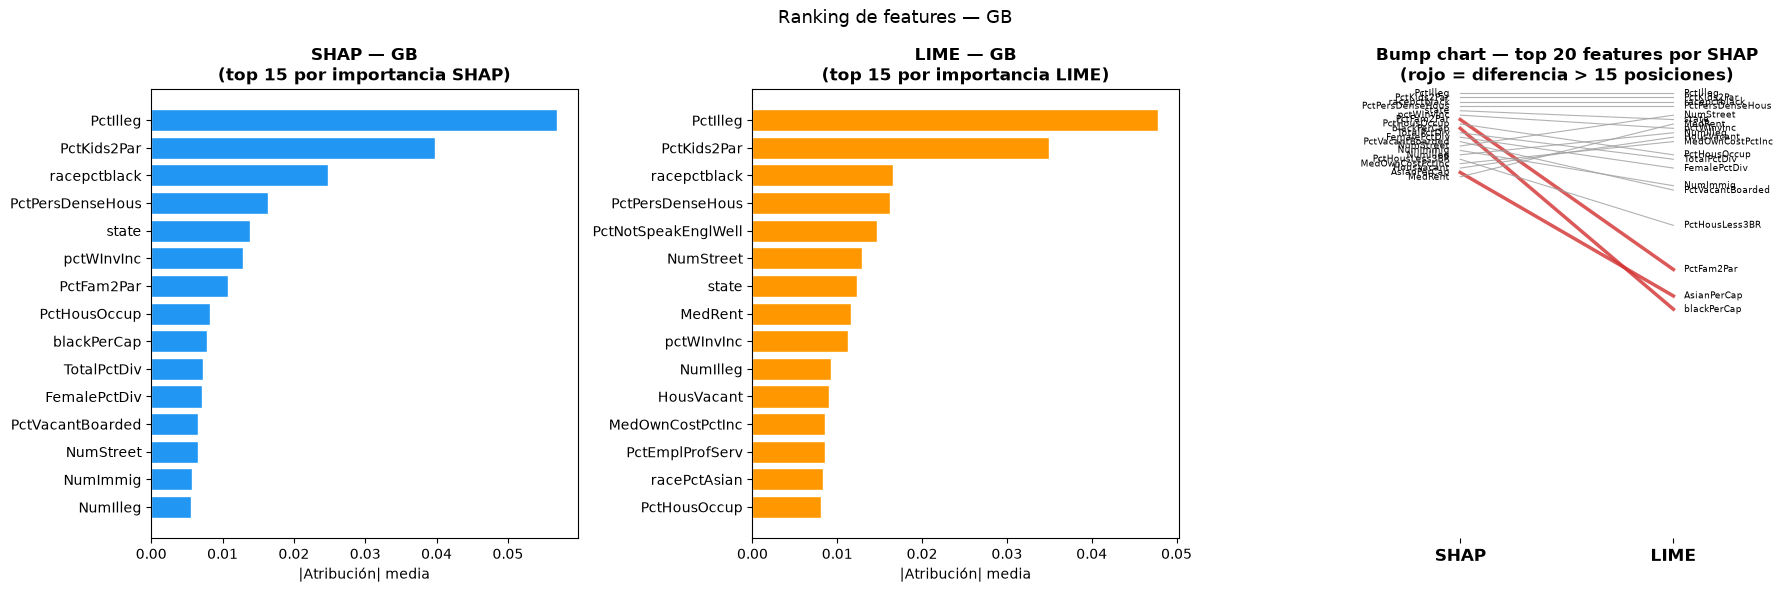


  Modelo: LR — Ranking completo de features (top 20 por SHAP)
           Feature  SHAP_mean_abs  LIME_mean_abs  SHAP_rank  LIME_rank  rank_diff
   PctPersOwnOccup       0.145969       0.155574          1          1          0
     PctHousOwnOcc       0.118073       0.126136          2          3         -1
      PctRecImmig8       0.113300       0.150907          3          2          1
    OwnOccLowQuart       0.087977       0.106383          4          4          0
  PersPerOccupHous       0.080672       0.100437          5          5          0
     PctRecImmig10       0.070631       0.094155          6          6          0
           MedRent       0.068389       0.072893          7          7          0
         medFamInc       0.061330       0.066011          8         10         -2
       whitePerCap       0.057203       0.069330          9          8          1
      OwnOccMedVal       0.055088       0.066129         10          9          1
      racepctblack       0.054094  

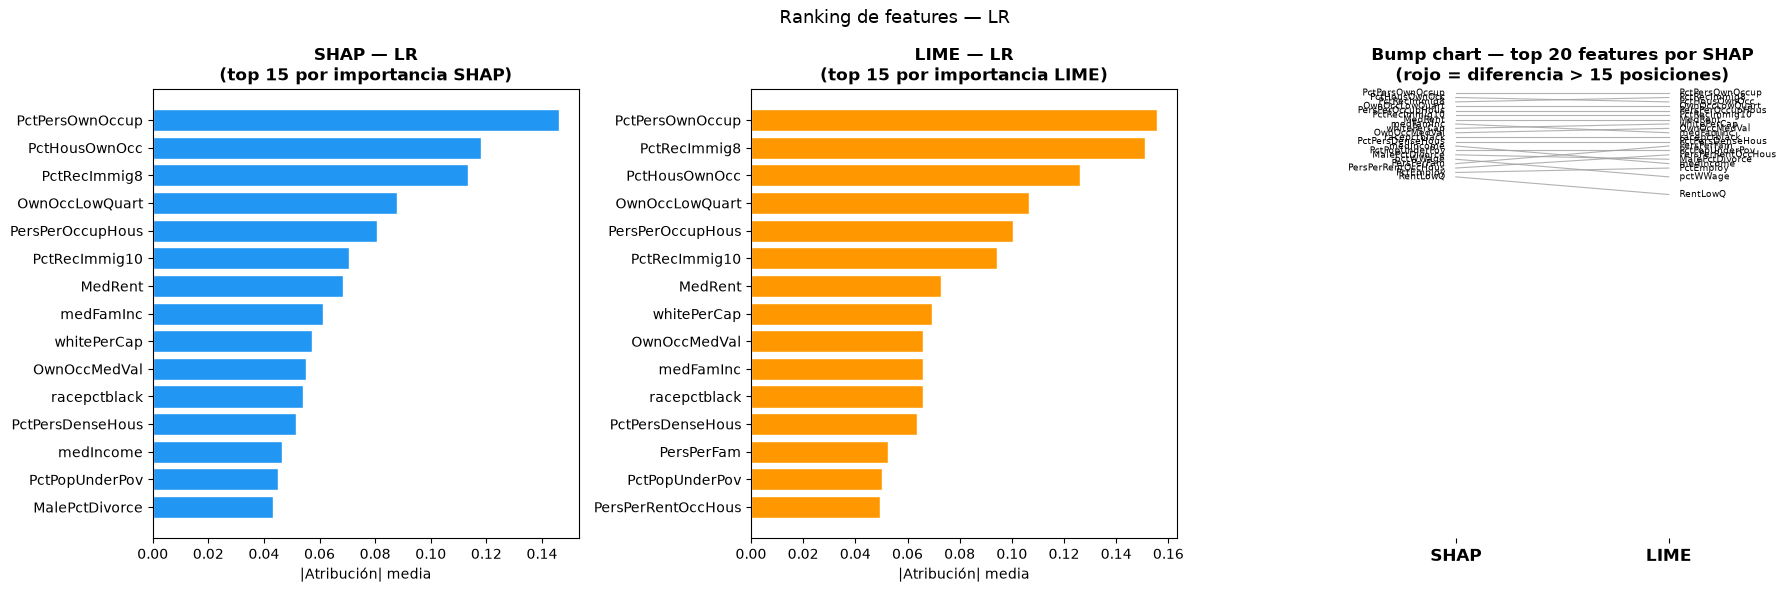

In [25]:
# ── Ranking completo de features por método ───────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

for name in selected_names:
    shap_a = shap_attributions[name]
    lime_a = lime_attributions[name]

    # Importancia media absoluta por feature
    shap_importance = np.abs(shap_a).mean(axis=0)
    lime_importance = np.abs(lime_a).mean(axis=0)

    ranking = pd.DataFrame({
        'Feature':         feature_names,
        'SHAP_mean_abs':   shap_importance,
        'LIME_mean_abs':   lime_importance,
        'SHAP_rank':       pd.Series(shap_importance).rank(ascending=False).astype(int).values,
        'LIME_rank':       pd.Series(lime_importance).rank(ascending=False).astype(int).values,
    }).sort_values('SHAP_rank')

    ranking['rank_diff'] = ranking['SHAP_rank'] - ranking['LIME_rank']

    print(f"\n{'='*65}")
    print(f"  Modelo: {name} — Ranking completo de features (top 20 por SHAP)")
    print(f"{'='*65}")
    print(ranking.head(20).to_string(index=False))

    # ── Visualización comparativa de rankings (top 15 por importancia) ────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    N_TOP_BAR = 15
    # Barplot SHAP
    shap_sorted = ranking.sort_values('SHAP_mean_abs', ascending=True).tail(N_TOP_BAR)
    axes[0].barh(shap_sorted['Feature'], shap_sorted['SHAP_mean_abs'],
                 color='#2196F3', edgecolor='white')
    axes[0].set_title(f'SHAP — {name}\n(top {N_TOP_BAR} por importancia SHAP)', fontweight='bold')
    axes[0].set_xlabel('|Atribución| media')

    # Barplot LIME
    lime_sorted = ranking.sort_values('LIME_mean_abs', ascending=True).tail(N_TOP_BAR)
    axes[1].barh(lime_sorted['Feature'], lime_sorted['LIME_mean_abs'],
                 color='#FF9800', edgecolor='white')
    axes[1].set_title(f'LIME — {name}\n(top {N_TOP_BAR} por importancia LIME)', fontweight='bold')
    axes[1].set_xlabel('|Atribución| media')

    # Bump chart: evolución del ranking entre métodos (top 20 features por SHAP)
    ax = axes[2]
    bump_features = ranking.head(20)
    for _, row in bump_features.iterrows():
        color = '#d32f2f' if abs(row['rank_diff']) > 15 else '#9e9e9e'
        lw    = 2.5 if abs(row['rank_diff']) > 15 else 0.8
        ax.plot([0, 1],
                [row['SHAP_rank'], row['LIME_rank']],
                color=color, lw=lw, alpha=0.8)
        ax.text(-0.05, row['SHAP_rank'], row['Feature'],
                ha='right', va='center', fontsize=6.5)
        ax.text(1.05, row['LIME_rank'], row['Feature'],
                ha='left', va='center', fontsize=6.5)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(len(feature_names) + 1, 0)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['SHAP', 'LIME'], fontsize=12, fontweight='bold')
    ax.set_ylabel('Ranking (1 = más importante)')
    ax.set_title(f'Bump chart — top 20 features por SHAP\n(rojo = diferencia > 15 posiciones)',
                 fontweight='bold')
    ax.yaxis.set_visible(False)
    ax.spines[['left','right','top','bottom']].set_visible(False)

    plt.suptitle(f'Ranking de features — {name}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [26]:
# ── Exportar valores de las feature attributions ───────────────
import os
import pandas as pd
import numpy as np

os.makedirs('results', exist_ok=True)

# Crear DataFrame base con los nombres de las features
attr_df = pd.DataFrame({'Feature': feature_names})

for name in selected_names:
    # 1. Procesar SHAP
    shap_vals = shap_attributions[name]
    attr_df[f'{name}_SHAP'] = np.abs(shap_vals).mean(axis=0)

    # 2. Procesar LIME
    lime_vals = lime_attributions[name]
    attr_df[f'{name}_LIME'] = np.abs(lime_vals).mean(axis=0)

# Exportar a CSV
export_path = os.path.join('results', 'feature_attributions_uscrime.csv')
attr_df.to_csv(export_path, index=False, sep=';')
print(f'\u2705 Valores de Atribucion (Media Absoluta) exportados a: {export_path}')
print(attr_df.head(27))

✅ Valores de Atribucion (Media Absoluta) exportados a: results\feature_attributions_uscrime.csv
          Feature   NB_SHAP   NB_LIME   GB_SHAP   GB_LIME   LR_SHAP   LR_LIME
0           state  0.010637  0.013898  0.013829  0.012336  0.009926  0.012965
1            fold  0.001502  0.001712  0.000612  0.002405  0.001142  0.001300
2      population  0.001181  0.003068  0.000194  0.000868  0.002021  0.005249
3   householdsize  0.004489  0.005982  0.000780  0.001969  0.000714  0.000952
4    racepctblack  0.041208  0.050107  0.024805  0.016553  0.054094  0.065751
5    racePctAsian  0.002009  0.003034  0.000329  0.008300  0.001070  0.001614
6     racePctHisp  0.002017  0.002714  0.003235  0.004279  0.005165  0.006949
7     agePct12t21  0.003149  0.005082  0.000279  0.001029  0.014677  0.023674
8     agePct12t29  0.013203  0.020320  0.002457  0.003301  0.015856  0.024403
9     agePct16t24  0.001958  0.003351  0.000324  0.000896  0.019189  0.032820
10     agePct65up  0.004577  0.005858  0.00051

In [27]:
# ── Porcentaje de coincidencia Top 15 (SHAP vs LIME) por modelo ──
top_k = 15
print(f"\n--- Coincidencia Top {top_k} features (SHAP vs LIME) ---")
overlap_results = {}

for name in selected_names:
    if f'{name}_SHAP' in attr_df.columns and f'{name}_LIME' in attr_df.columns:
        # Obtener los top K features para SHAP y LIME
        top_shap = set(attr_df.nlargest(top_k, f'{name}_SHAP')['Feature'])
        top_lime = set(attr_df.nlargest(top_k, f'{name}_LIME')['Feature'])

        # Calcular intersección
        intersection = top_shap.intersection(top_lime)
        overlap_pct = (len(intersection) / top_k) * 100
        overlap_results[name] = overlap_pct

        print(f'\u2705 Modelo {name}: {overlap_pct:.2f}% de coincidencia ({len(intersection)}/{top_k} features)')
        print(f'   Features en común: {", ".join(intersection)}\n')


--- Coincidencia Top 15 features (SHAP vs LIME) ---
✅ Modelo NB: 86.67% de coincidencia (13/15 features)
   Features en común: racepctblack, PctIlleg, agePct12t29, PctKids2Par, RentLowQ, PctPopUnderPov, PctPersDenseHous, pctWInvInc, PctFam2Par, PctWorkMom, MalePctDivorce, MedRent, MalePctNevMarr

✅ Modelo GB: 60.00% de coincidencia (9/15 features)
   Features en común: NumStreet, PctIlleg, state, PctKids2Par, PctHousOccup, PctPersDenseHous, NumIlleg, pctWInvInc, racepctblack

✅ Modelo LR: 86.67% de coincidencia (13/15 features)
   Features en común: OwnOccLowQuart, PctRecImmig10, PctPersOwnOccup, whitePerCap, PersPerOccupHous, medFamInc, OwnOccMedVal, PctHousOwnOcc, PctPersDenseHous, PctPopUnderPov, PctRecImmig8, racepctblack, MedRent

